<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/05_Attention/Seq2seq%E1%84%8B%E1%85%AA_Attention_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 들어가며

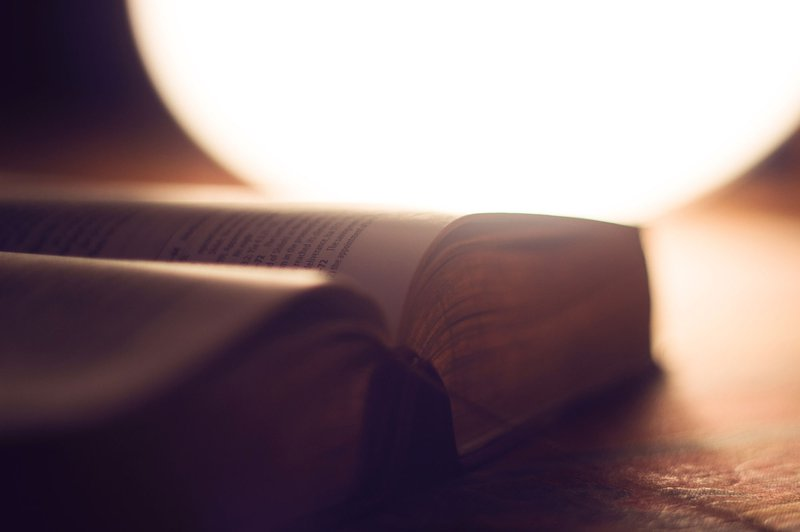

문장을 토큰화하고 의미를 부여하는 과정은 멋지고 중요한 일이지만 조금은 지루할 수 있죠. 그 과정을 견디고 여기까지 오신 여러분, 고생하셨습니다!

이번 코스에서는 언어 모델이 발전해 온 과정에 대해 개략적으로 공부하고, NLP의 큰 흐름 중 하나인 **Sequence to Sequence(Seq2seq)** 에 대해 살펴볼 것입니다. 이를 발전시키기 위한 기법이자 지금은 없어선 안 될 중요한 메커니즘인 **Attention**에 대해서도 최초의 아이디어가 생겨난 시점에서부터 자세히 살펴보려고 합니다. 부디 즐거운 시간이 되시길 바랍니다!

**[아이스브레이킹] 문장을 토큰화하고 의미를 부여하는 일이 뭐였죠?**

<details>
<summary>💡예시답안 확인하기💡</summary>

문장을 토큰화하고 의미를 부여하는 과정은 자연어 처리 분야에서 중요한 전처리 과정입니다.

토큰화란 문장을 단어, 구두점, 숫자 등의 작은 단위로 분할하는 과정입니다. 이를 통해 각각의 단어를 기본적인 처리 단위로 사용할 수 있습니다. 의미 부여는 각 단어에 대한 의미를 부여하여 문장 전체의 의미를 파악합니다.

이러한 과정을 통해 문장의 구조와 의미를 파악할 수 있으며, 이를 기반으로 다양한 자연어 처리 작업을 수행할 수 있습니다. 예를 들어, 기계 번역, 문서 분류, 감성 분석 등의 작업에서는 문장을 토큰화하고 의미를 부여하여 작업을 수행합니다.
</details>

## 학습 내용
---
- 2. 우리가 만드는 언어 모델  
언어 모델을 학습합니다.

- 3. Sequence to Sequence 문제  
seq2seq 문제가 무엇인지 학습합니다.

- 4. Sequence to Sequence 구현  
seq2seq를 Pytorch로 구현합니다.

- 5. Attention! (1) Bahdanau Attention  
Bahdanau Attention을 학습합니다.

- 6. Attention! (2) Luong Attention  
Luong Attention을 학습합니다.

- 7. 트랜스포머로 가기 전 징검다리?  
트랜스포머가 무엇일지 생각합니다.

## 학습 목표
---
- 언어 모델이 발전해 온 과정을 개략적으로 설명할 수 있다.
- 기존 RNN 기법이 번역에서 보인 한계를 파악하고, 이를 개선한 Seq2seq를 이해할 수 있다.
- Seq2seq를 발전시킨 Attention에 대해 설명할 수 있다.

# 우리가 만드는 언어 모델
언어 모델(Language Model)이란, 주어진 단어들을 보고 다음 단어를 맞추는 모델입니다. 더 자세하게는, **단어의 시퀀스를 보고 다음 단어에 확률을 할당** 하는 모델이죠!

좀 더 수학적으로 표현하자면, 언어 모델은 n-1개의 단어 시퀀스 $\text{w}_{1}, \cdots, \text{w}_{n-1}$가 주어졌을 때, n번째 단어 $\text{w}_{n-1}$으로 무엇이 올지를 예측하는 확률 모델로 표현됩니다. 파라미터 $\theta$로 모델링하는 언어 모델을 다음과 같이 표현할 수 있습니다.

$$\text{P}(\text{w}_{n}|\text{w}_{1},\cdots,\text{w}_{n-1};\theta)$$

하지만 나중에는 꼭 시퀀스 형태의 Next Token Prediction 언어모델이 아니더라도, 주변 단어를 보고 중심 단어를 예측하는 형태로 언어모델을 구성하는 것도 보시게 될 것입니다.

## 통계적 언어 모델 (Statistical Language Model)
---
딥러닝이 등장하기 이전엔 **통계적 언어 모델(Statistical Language Model)** 의 사용이 지배적이었습니다. 대표적으로 2000년대 초반까지 구글이나 네이버의 번역기는 모두 통계적 언어 모델을 기반으로 하고 있었죠. 통계적 언어 모델의 이모저모를 배우기 위해 아래 웹페이지를 방문해 보세요.

- [언어모델(Language Model)](https://ratsgo.github.io/from%20frequency%20to%20semantics/2017/09/16/LM/)

**Q. 위 글에서 설명하는 언어 모델은 충분한 데이터가 없다면 범용적인 모델을 구축하기 어렵습니다. 그 이유에 대해 간단히 적어보세요.**

<details>
<summary>💡예시답안 확인하기💡</summary>

한 번도 본 적 없는(학습 데이터에 존재하지 않는) 단어 / 문장에 대해서는 확률을 부여할 수 없다. 따라서 언어 모델이 아우르는 범위를 넓히기 위해 다양한 단어를 포함하는 데이터가 필요하다. (양까지 충분하다면 정의하는 확률이 일반적이므로 더욱 좋다.)
</details>

`등장한 적 없는 단어나 문장에 대해 모델링을 할 수 없다`는 통계적 언어 모델의 단점은 치명적이었습니다. 데이터가 아무리 많다고 해도 세상 모든 단어를 포함할 수는 없었으니 말이죠.

## 신경망 언어 모델 (Neural Network Language Model)
---
통계적 언어 모델의 단점을 개선한 것이 우리가 배울 **신경망 언어 모델(Neural Network Language Model, 이하 NNLM)** 입니다. NNLM의 시초는 Feed-Forward 신경망 언어 모델인데, 지금의 Embedding 레이어의 아이디어인 모델입니다. 이에 대한 설명이 아래 웹페이지에 아주 잘 되어 있습니다.

- [피드 포워드 신경망 언어 모델(NNLM)](https://wikidocs.net/45609)

**Q. 위 글에서 설명하는 희소문제(sparsity problem)에 대해 간단히 설명해 보세요.**

<details>
<summary>💡예시답안 확인하기💡</summary>

희소 문제란, 모델이 충분한 데이터를 관측하지 못하면 언어를 정확히 모델링 할 수 없는 문제를 말한다. 한 번도 관측하지 못한 데이터에 대해선 0에 확률을 부여한다는 것에서 문제가 발생한다.
</details>

**Q. 원-핫 입력이 투사층을 거쳐가는 것은 해당 행을 읽어오는 것과 동일하다는 데에서 붙여진 이름은 무엇인가요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

룩 업 테이블(Lookup Table)
</details>

**Q. 출력 층에서 사용되는 활성함수 Softmax는 어떤 의미를 갖나요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

소프트맥스 함수를 거쳐 나온 0-1 사이 값은 해당 인덱스에 대한 확률을 의미한다.
</details>

단어를 어떤 Embedding으로 표현할 수 있다는 것은 어떤 이점을 가질까요? 단순 유사도 비교를 넘어서는 활용 사례를 아래 영상에서 확인해보세요!

[![image](https://img.youtube.com/vi/gUMvBRI-WGo/0.jpg)](https://youtu.be/gUMvBRI-WGo)

각 단어를 일련의 Embedding 벡터로 표현한 후, 이전의 몇 개 단어를 활용해 다음 단어를 예측하는 것은 분명 많은 문제를 해결했습니다. 특히 `단어 간의 유사도를 표현할 수 있게 되어` 문장의 유창성이 높아진 것은 혁신적이었죠!

하지만 예측에 `정해진 개수의 단어만 참고한다`는 분명한 한계가 있었습니다. 예를 들어 번역문을 생성하려면 문장이 짧을 수도, 길 수도 있으니, n개의 단어를 참고하기보다는 "몇 개 단어가 들어와도 문장 단위로 처리한다!"는 종류의 모델링이 필요하게 되었죠. 그렇게 고안된 것이 바로 여러분들이 잘 알고 계신 **순환 신경망(Recurrent Neural Network, 이하 RNN)을 활용한 언어 모델** 입니다. 이에 대한 설명은 다음 스텝에서 이어갈게요!

# Sequence to Sequence 문제

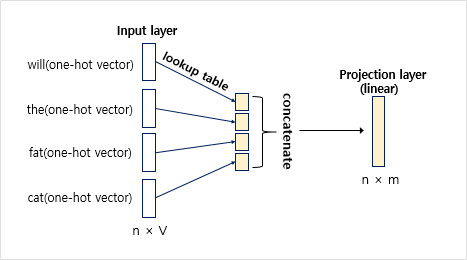

[NNLM의 구조]

https://wikidocs.net/45609

다시 한번 설명하면, 여러 개의 단어(Embedding)를 합쳐(Concatenate) 고정된 크기의 Weight를 Linear로 처리하는 방식은 유연성에 한계가 있었습니다. 단어의 개수에 무관하게 처리할 수 있는 네트워크가 필요했고, 그것은 곧 **RNN의 고안**으로 이어졌습니다. RNN은 고정된 크기의 Weight가 선언되는 것은 동일하지만 입력을 **순차적으로 "적립"하는 방식**을 채택함으로써 유동적인 크기의 입력을 처리할 수 있었습니다.

"**적립**"이라는 표현을 일반적으로 사용하지는 않습니다만, 필자가 생각하기에 RNN의 동작 방식에 잘 어울린다고 생각해 선택했습니다. 기억, 누적, 압축 등으로 대체할 수 있으며 가장 와닿는 방향으로 이해하세요!

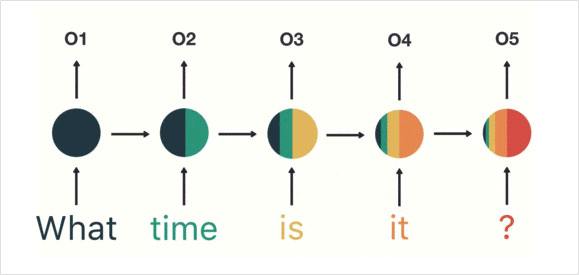

https://towardsdatascience.com/illustrated-guide-to-recurrent-neural-networks-79e5eb8049c9

단어가 자체적으로 의미를 가질 수 있는 Embedding을 도입하고, 입력의 유연성을 위해 RNN도 적용했는데, 아직도 해결할 문제가 있을까요? 물론입니다! 대표적으로 RNN에는 **두 가지 문제점**이 꼽히곤 합니다.

1. 하나의 Weight에 입력을 적립하다 보니 입력이 길어질수록 이전 입력에 대한 정보가 소실되는 **기울기 소실(Vanishing Gradient)** 문제가 있습니다. 위의 그림을 보면 각 입력마다 정보를 색으로 확인할 수 있습니다. 첫 입력인 `What(남색)`의 정보가 마지막 입력인 `?`에 다다라서는 **거의 희석된 모습**을 보여주고 있죠. 이 문제는 LSTM을 고안함으로써 개선되었습니다. LSTM에 대한 자세한 내용은 이미 알고 계신다고 생각하겠습니다. 기억이 잘 나지 않는 분은 아래 링크를 참고해 주세요.

- [Long Short-Term Memory (LSTM) 이해하기](https://dgkim5360.tistory.com/entry/understanding-long-short-term-memory-lstm-kr)

2. 단어 단위로 입력과 출력을 순환하는 RNN 구조는 문장 생성엔 적합할지언정 **번역에 사용하기는 어렵다는 문제가 있습니다**. `나는 점심을 먹는다` 라는 문장을 영문으로 번역하자면 목표 문장은 `I eat lunch` 가 될 것인데, 과정을 순차적으로 생각하면 `eat` 이라는 단어를 만들 때는 먹는다 에 대한 정보가 없습니다. 각 언어별로 어순이 다르기 때문입니다.

> 나는 -> I
>
> 나는 점심을 -> I lunch
>
> 나는 점심을 먹는다 -> I lunch eat(?)

심지어 입력의 길이와 번역의 길이가 같다는 보장도 없죠. 번역에 있어서는 문장을 다 읽고 번역하는, 즉 **문장 전체를 보고 나서 생성하는 구조**가 필요했습니다. 이에 2014년, 구글이 *Sequence to Sequence(Seq2Seq)* 구조를 제안합니다.

- 논문: [Sequence to Sequence Learning with Neural Networks](https://papers.nips.cc/paper/5346-sequence-to-sequence-learning-with-neural-networks.pdf)

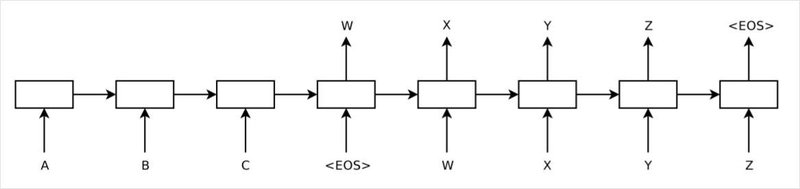

[Sequence to Sequence Learning with Neural Networks]

https://papers.nips.cc/paper/5346-sequence-to-sequence-learning-with-neural-networks.pdf

이를 멋지게 정리한 글을 함께 첨부합니다.

- [Seq2seq (2): Sequence to Sequence Learning with Neural Networks](https://reniew.github.io/35/)

**Q. seq2seq의 저자들은 단순한 RNN 대신 LSTM을 사용하고자 하였습니다. 그 이유를 간단히 서술하고 논문에서 해당 내용이 포함된 문단을 찾아보세요.**

<details>
<summary>💡예시답안 확인하기💡</summary>

단순한 RNN은 긴 입력에 대한 정보를 학습시키기 어렵기 때문이다.

A simple strategy for general sequence learning is to map the input sequence to a fixed-sized vector using one RNN, and then to map the vector to the target sequence with another RNN (this approach has also been taken by Cho et al. 5). While it could work in principle since the RNN is provided with all the relevant information, it would be difficult to train the RNNs due to the resulting long term dependencies 14, 4 (figure 1) 16, 15. However, the Long Short-Term Memory (LSTM) 16 is known to learn problems with long range temporal dependencies, so an LSTM may succeed in this setting.
</details>

**<식 1>**

$$p\left(y_1, \ldots, y_{T^{\prime}} \mid x_1, \ldots, x_T\right)=\Pi_{t=1}^{T^{\prime}} p\left(y_t \mid v, y_1, \ldots, y_{t-1}\right)$$

**Q. 위의 <식 1>을 보고 각 x와 y, v가 무엇을 의미하는지 설명하세요. 그리고 v의 정의를 논문에서 찾아보세요.**

<details>
<summary>💡예시답안 확인하기💡</summary>

x: Input Sequence \
y: Output Sequence \
v: 인코더의 입력 x에 대한 고정된 크기의 Representation Vector 아웃풋으로서, 디코더의 입력으로 사용됨 The LSTM computes this conditional probability by first obtaining the fixed-dimensional representation v of the input sequence (x1, . . . , xT ) given by the last hidden state of the LSTM...
</details>

**Q. 논문의 2. The Model의 마지막 문단은 입력과 출력의 "establish communication"에 대해 설명하고 있습니다. 이에 대해 이해한 대로 설명해보세요.**

<details>
<summary>💡예시답안 확인하기💡</summary>

입력 abc와 출력 def에 대해 a->d, b->e, c->f의 관계를 가진다면 입력을 cba로 뒤집어도 관련 있는 단어 사이의 평균 거리는 같게 유지된다. 그런데 a와 d의 거리는 매우 가까워지고, b와 e의 거리는 상당히 가까워진다. 이런 변형은 SGD가 입출력 간의 구조적 관계를 파악하는 것을 용이하게 하고 LSTM에 대해 성능을 Boost하는 효과가 있다. 특히 논문의 3.3 Reversing the Source Sentences 두 번째 문단을 보면, 단어 사이의 평균 거리는 유지되면서 문장의 앞 부분 단어의 거리가 줄어들기 때문에 학습 효과가 높아지는 것으로 추측하고 있다.
</details>

윗글은 논문의 내용에 포커싱이 되어있다면 아랫글은 작동 방식에 대한 조금 더 자세한 설명을 포함합니다. 윗글을 잘 이해했다면 아랫글을 읽으며 복습하고 논문에는 언급되어 있지 않은 디테일한 내용을 파악하도록 합시다. 글 내용 중 `1. 시퀀스-투-시퀀스(Sequence-to-Sequence)` 부분을 읽어보세요!

- [시퀀스-투-시퀀스](https://wikidocs.net/24996)

**Q. Encoder은 입력 문장의 모든 단어들을 순차적으로 입력받고 모든 단어를 압축한 단 하나의 [    ]를 만듭니다. 빈칸에 들어갈 단어는 무엇인가요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

컨텍스트 벡터(Context Vector)
</details>

**Q. 문장의 시작과 끝에 붙는 특수한 토큰들이 있습니다. 만약 그 토큰들이 없다면 어떻게 될까요? 시작 토큰이 없는 경우와 끝 토큰이 없는 경우를 나누어 적어봅시다.**

<details>
<summary>💡예시답안 확인하기💡</summary>

시작 토큰이 없는 경우, Decoder의 첫 입력으로 전달할 단어가 없어져 번역을 진행할 수 없다. 만일 랜덤한 단어를 입력으로 넣는 경우, 번역의 성능에 문제가 생긴다. 끝 토큰이 없는 경우, 문장의 끝을 알릴 수 없어 단어를 무한정 생성하게 된다. 온점이나 느낌표 등을 끝 토큰으로 사용하기엔 불안정한 성능을 보일 것이다.
</details>

**Q. 글 말미에 이번 코스의 스포일러가 담겨있네요! 문맥을 더 잘 반영하는 벡터를 생성하는 메커니즘이 있는데, 이름이 뭔가요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

어텐션 메커니즘(Attention)
</details>

# Sequence to Sequence 구현
이제 Sequence to Sequence를 `Pytorch`로 구현해보죠. 일단은 데이터를 직접 다루기보다는 차원 수를 확인하는 실습을 해보겠습니다. RNN 계통의 레이어들은 입력값과 반환값이 설정에 따라 각양각색입니다. 이번 구현에서는 입력으로 **Embedding된 단어만 전달**하고 (Hidden State는 전달하지 않습니다), 출력은 Encoder와 Decoder 별로 상이하므로 각각 설명을 첨부하겠습니다.

## LSTM Encoder
---

In [ ]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        # print("입력 Shape:", src.size())

        embedded = self.embedding(src)
        # print("Embedding Layer를 거친 Shape:", embedded.size())

        outputs, (h_0, c_0) = self.rnn(embedded)
        # print("LSTM Layer의 Output Shape:", outputs.size())
        # print("LSTM Layer의 Hidden State Shape:", h_0.size())
        # print("LSTM Layer의 Cell State Shape:", c_0.size())
        # (위 4개의 print문은 학습 루프에서 배치마다 반복 호출되면 출력이 폭주하므로 주석 처리했습니다.
        #  구조를 다시 확인하고 싶다면 주석을 풀고 cell 39의 샘플 입력으로 한 번만 실행해보세요.)

        return outputs, h_0, c_0

print("슝~")


슝~


This cell defines an `Encoder` class, which is a PyTorch `nn.Module`. It initializes an embedding layer and an LSTM layer. The `forward` method takes an input `src`, embeds it, passes it through the LSTM, and prints the shapes at each step. It returns the LSTM outputs, the final hidden state (`h_0`), and the final cell state (`c_0`).

Embedding 레이어를 단어 사이즈와 Embedding 차원에 대해 선언을 한 후, 논문에서 소개한 대로 `torch.nn.LSTM(enc_units)`으로 LSTM을 정의합니다. *Pytorch* 속 LSTM 모듈의 기본 반환 값은 **최종 State 값**이므로 `return_sequences` 나 `return_state` 값은 따로 조정하지 않습니다 (기본: False). 즉, 우리가 정의해 준 `Encoder` 클래스의 반환 값이 곧 **컨텍스트 벡터(Context Vector)** 가 되는 겁니다. 추가적인 옵션이 궁금하시다면 아래의 Pytorch LSTM 공식 문서를 참조하시면 좋습니다.

- [torch.nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)

In [ ]:
vocab_size = 30000
emb_size = 256
lstm_size = 512
batch_size = 1
sample_seq_len = 3

print("Vocab Size: {0}".format(vocab_size))
print("Embedidng Size: {0}".format(emb_size))
print("LSTM Size: {0}".format(lstm_size))
print("Batch Size: {0}".format(batch_size))
print("Sample Sequence Length: {0}\n".format(sample_seq_len))

Vocab Size: 30000
Embedidng Size: 256
LSTM Size: 512
Batch Size: 1
Sample Sequence Length: 3



This cell defines various parameters that will be used for the Encoder and Decoder, such as the vocabulary size, embedding size, LSTM hidden dimension size, batch size, and sample sequence length. It then prints these parameters.

In [ ]:
import torch

encoder = Encoder(vocab_size, emb_size, lstm_size)
sample_input = torch.randint(0, vocab_size, (batch_size, sample_seq_len))

sample_output, hidden, cell = encoder(sample_input)

This cell imports `torch`, then creates an instance of the `Encoder` class with the defined parameters. It generates a sample input tensor with random integers representing token IDs and passes it through the encoder. The shapes of the output, hidden state, and cell state are printed as defined in the `Encoder`'s `forward` method.

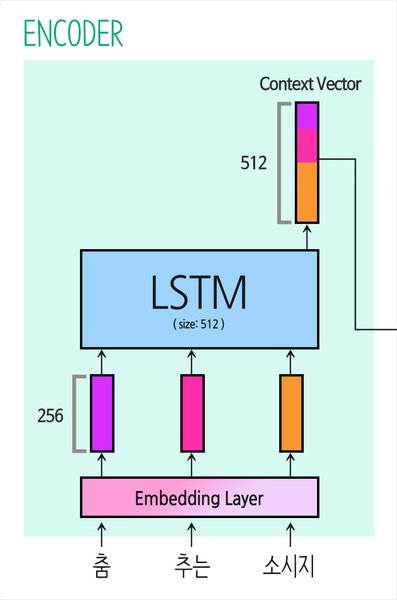

[예시 코드와 동일한 Shape를 가지는 Encoder 구조]

아주 간편하게 `Encoder` 클래스를 정의했습니다. 어떤 Source 문장을 `Encoder`에 읽히고, 그 반환 값인 LSTM의 최종 State 값을 `Decoder`에게 전달해 주면 되겠죠?

> **실행 순서 안내**: 아래 `Decoder` 클래스는 내부적으로 `BahdanauAttention`을 사용합니다. `BahdanauAttention`에 대한 자세한 설명과 시각화는 뒤쪽 **"Attention! (1) Bahdanau Attention"** 섹션에서 이어지지만, 코드가 순서대로 (위에서 아래로) 실행될 수 있도록 여기서 미리 클래스만 정의해둡니다.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W_decoder = nn.Linear(512, units)  # Decoder hidden state -> units
        self.W_encoder = nn.Linear(512, units)  # Encoder hidden state -> units
        self.W_combine = nn.Linear(units, 1)   # Alignment score -> scalar weight

    def forward(self, H_encoder, H_decoder):
        # 원본 H_encoder는 그대로 보존하고, Score 계산용으로만 units 차원으로 매핑합니다.
        encoder_features = self.W_encoder(H_encoder)  # (batch, seq_len, units)

        H_decoder = H_decoder.unsqueeze(1)  # (batch, 1, hidden_dim)
        decoder_features = self.W_decoder(H_decoder)  # (batch, 1, units)

        score = self.W_combine(torch.tanh(decoder_features + encoder_features))  # (batch, seq_len, 1)
        attention_weights = F.softmax(score, dim=1)  # (batch, seq_len, 1)

        # Context Vector = 원본 Encoder Hidden State들의 가중합
        context_vector = attention_weights * H_encoder  # (batch, seq_len, hidden_dim)
        context_vector = torch.sum(context_vector, dim=1)  # (batch, hidden_dim)

        return context_vector, attention_weights

print("BahdanauAttention 클래스 정의 완료 (Decoder에서 바로 사용하기 위해 미리 정의)")

BahdanauAttention 클래스 정의 완료 (Decoder에서 바로 사용하기 위해 미리 정의)


## LSTM Decoder
---

In [ ]:
import torch.nn.functional as F

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(Decoder, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim # Store hidden_dim for attention
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # The LSTM now takes embedded input (embedding_dim) + context vector (hidden_dim)
        self.lstm = nn.LSTM(embedding_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        # Instantiate BahdanauAttention
        self.attention = BahdanauAttention(hidden_dim) # Using hidden_dim for units

    def forward(self, x, hidden, cell, encoder_outputs):
        # x: current input token (batch_size, 1)
        # hidden: decoder's previous hidden state (1, batch_size, hidden_dim)
        # cell: decoder's previous cell state (1, batch_size, hidden_dim)
        # encoder_outputs: all encoder hidden states (batch_size, seq_len, hidden_dim)

        # embedded: (batch_size, 1, embedding_dim)
        embedded = self.embedding(x)

        # hidden state of the decoder for attention calculation
        # BahdanauAttention expects H_decoder shape (batch, hidden_dim)
        # hidden from LSTM is (num_layers * num_directions, batch, hidden_size)
        # So we squeeze the num_layers dimension (assuming 1 layer, 1 direction)
        decoder_hidden_for_attention = hidden.squeeze(0) # (batch_size, hidden_dim)

        # Calculate context vector using Bahdanau Attention
        context_vector, attention_weights = self.attention(encoder_outputs, decoder_hidden_for_attention)
        # context_vector: (batch_size, hidden_dim)
        # attention_weights: (batch_size, encoder_seq_len, 1) or (batch_size, encoder_seq_len)

        # Reshape context_vector to (batch_size, 1, hidden_dim) for concatenation
        context_vector = context_vector.unsqueeze(1)

        # Concatenate embedded input with context vector
        # Result: (batch_size, 1, embedding_dim + hidden_dim)
        embedded_with_context = torch.cat((embedded, context_vector), dim=2)

        output, (hidden, cell) = self.lstm(embedded_with_context, (hidden, cell))
        # output: (batch_size, 1, hidden_dim)
        # hidden: (1, batch_size, hidden_dim)
        # cell: (1, batch_size, hidden_dim)

        # Final prediction from the fully connected layer
        # output.squeeze(1) changes (batch_size, 1, hidden_dim) to (batch_size, hidden_dim)
        output = self.fc(output.squeeze(1))
        # output: (batch_size, vocab_size)

        return output, hidden, cell

This cell defines the `Decoder` class, which is also a PyTorch `nn.Module`. It has an embedding layer, an LSTM layer, and a fully connected (Linear) layer. The key difference from the Encoder's LSTM is that its input combines the embedded token with a context vector. The `forward` method takes the current input `x`, the hidden and cell states from the previous time step, and the `context` vector (which would typically come from the encoder). It embeds the input, concatenates it with the `context`, passes it through the LSTM, and then through a linear layer to produce the final output. It prints the shapes at various stages.

`Decoder`는 `Encoder`와 구조적으로 유사하지만 결과물을 생성해야 하므로 Fully Connected 레이어가 추가되었고, 출력값을 확률로 변환해 주는 Softmax 함수도 추가되었습니다 (Softmax는 모델 내부에 포함시키지 않아도 훈련 과정에서 포함시키는 방법도 있습니다). 그리고 `Decoder`가 매 스텝 생성하는 출력은 우리가 원하는 번역 결과에 해당하므로 LSTM 레이어의 `return_sequences` 변수를 `True`로 설정하여 State 값이 아닌 Sequence 값을 출력으로 받습니다.

In [ ]:
decoder_input = torch.randint(0, vocab_size, (batch_size, 1))  # (batch_size, 1) -> Represents one token

decoder = Decoder(vocab_size, emb_size, lstm_size)

dec_output, hidden, cell = decoder(decoder_input, hidden, cell, sample_output)

This cell creates a sample input for the decoder and then instantiates the `Decoder` class with the defined parameters. It then calls the `decoder`'s `forward` method, passing the sample decoder input, and the `hidden` and `cell` states along with `sample_output` (acting as the context vector) obtained from the `Encoder`. The `Decoder`'s output, and its final hidden and cell states are returned.

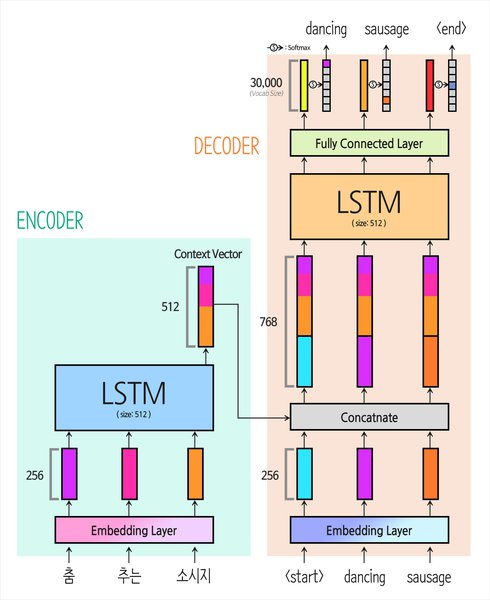

[예시 코드와 동일한 Shape를 가지는 Seq2seq 구조]

이 수식을 기억하시나요?

$$p\left(y_1, \ldots, y_{T^{\prime}} \mid x_1, \ldots, x_T\right)=\Pi_{t=1}^{T^{\prime}} p\left(y_t \mid v, y_1, \ldots, y_{t-1}\right)$$

`Encoder`가 생성한 컨텍스트 벡터 v 를 Embedding 레이어를 거친 y 값에 Concatnate하여 위 수식을 비로소 만족하게 됩니다. 우리가 Seq2seq를 완성한 거죠!

# Attention! (1) Bahdanau Attention

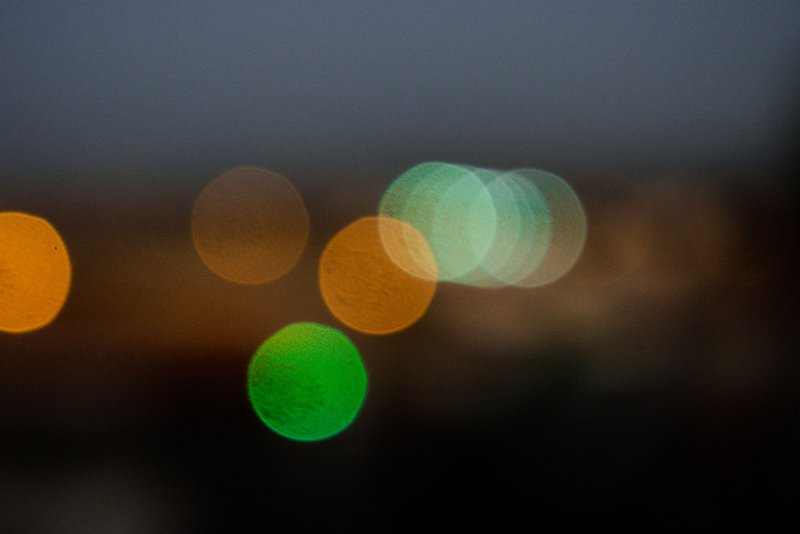

혁신적이었던 Seq2Seq은 Encoder-Decoder 구조라는 딥러닝 모델의 큰 틀을 제시했고, 지금까지도 그 구조는 널리 활용되고 있습니다. 하지만 그것만으로 기계 번역이 완벽했다면 우리는 이미 외국어에 대한 두려움이 사라졌겠죠?

Seq2Seq 역시 여느 기법처럼 한계점이 존재했으며 이를 발전시키려는 시도가 아주 많았습니다. 가장 대표적인 방법이 바로 **Attention 메커니즘**입니다! 이번 스텝에서는 Attention 메커니즘의 이모저모를 살펴볼 거예요!

## Bahdanau Attention
---

장점으로 보이는 어떤 것도 누군가에게는 결점이 보이는 법이죠. Bahdanau는 Seq2Seq의 **컨텍스트 벡터가 고정된 길이로 정보를 압축하는 것이 손실을 야기한다**고 주장하였습니다. 즉 짧은 문장에 대해서는 괜찮을지 모르겠으나 문장이 길어질수록 성능이 저하된다는 것이지요. 콜럼버스의 달걀처럼, 듣고 보니 그럴듯합니다!

이에 그는 Encoder의 최종 State 값만을 사용하는 기존의 방식이 아닌, 매 스텝의 Hidden State를 활용해 컨텍스트 벡터를 구축하는 **Attention 메커니즘**을 제안합니다.

아래는 Bahdanau의 Attention 논문입니다. 내용이 제법 어렵지만 must-read 논문이니만큼, 꼭 한번 읽어보시기를 권합니다. 하지만 지금은 소개해 드릴 정리 글과 시각화 자료를 통해 조금 더 쉽게 이해해보세요!

- 원본 논문: [NEURAL MACHINE TRANSLATION BY JOINTLY LEARNING TO ALIGN AND TRANSLATE](https://arxiv.org/pdf/1409.0473.pdf)

- 정리 글: [Attention mechanism in NLP. From seq2seq + attention to BERT](https://lovit.github.io/machine%20learning/2019/03/17/attention_in_nlp/) (지금까지 배운 것을 확인하기에도 아주 좋습니다!)

**Q. 블로그 저자의 사견에 따르면 모델의 성능 향상 외에 Attention을 활용할 수 있는 방법이 하나 있습니다. 부산물이라고 표현된 그 방법은 무엇인가요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

Attention Map의 시각화를 통해 모델의 안정성을 점검할 수 있고, 모델이 의도와 다르게 작동될 경우 그 원인을 찾아내는 데에 이용될 수 있다.
</details>

**Q. Sequence Labeling과 Sequence to Sequence의 예시를 하나씩 적고, 두 Task의 차이점에 대해 간단히 설명해봅시다.**


<details>
<summary>💡예시답안 확인하기💡</summary>

Sequence Labeling: 품사 태깅

Sequence to Sequence: 번역
</details>

## seq2seq과 attn-seq2seq, 뭐가 다른가?
---
Attention의 개념에 대해 어려워하는 분들이 많습니다. 이렇게 생각해 봅시다. Attention이 없는 것과 있는 것은 과연 뭐가 달라지는 것일까?

- seq2seq
$$p\left(y_i \mid y_1, \ldots, y_{i-1}, \mathbf{x}\right)=g\left(y_{i-1}, s_i, c\right)$$

- attention
$$p\left(y_i \mid y_1, \ldots, y_{i-1}, \mathbf{x}\right)=g\left(y_{i-1}, s_i, c_{i}\right)$$

위의 두 식을 비교해 봅시다. Bahdanau 논문 원문에 나오는 Encoder-Decoder 구조에 대한 수식을 seq2seq만 있는 경우와 attention이 적용된 경우로 나누어 비교해 보면, 약간의 notation을 수정해서 보면 단 한 군데만 빼고는 사실상 동일합니다. 어디가 다른지 눈에 띄시나요?

네 그렇습니다. 유일한 차이는 attention이 있는 경우엔 바로 context vector c에 첨자 i가 붙어있다는 점입니다. 그렇다면 이 작은 첨자 하나가 어떤 근본적인 차이를 가져오게 되는 것인지 생각해 볼까요?

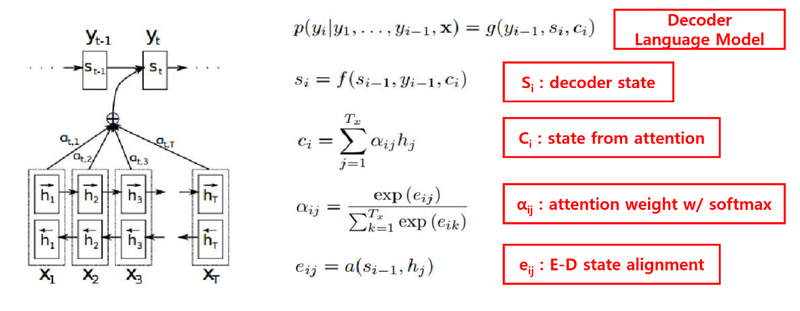

위 그림은 Bahdanau 논문 원문의 3.LEARNING TO ALIGN AND TRANSLATE의 내용을 바탕으로 재구성한 것입니다. 위 그림의 왼쪽 부분은 $\textbf{X}_{j}$를 입력으로, $\textbf{y}_{i}$를 출력으로 하는 인코더-디코더 부분을 도식화한 것입니다. 여기서 유의해야 할 점은 **$i$는 디코더의 인덱스, $j$는 인코더의 인덱스**라는 점입니다.

그렇다면 context vector c에 첨자 i가 붙어 $c_{i}$가 된다는 것의 의미는 무엇일까요?

>인코더가 X를 해석한 context $c_{i}$는 디코더의 포지션 i에 따라 다르게 표현(represent)되어야 한다.

seq2seq의 인코더가 해석한 context는 디코더의 포지션 i에 무관하게 항상 일정했습니다. 그러나 attention이 가미되면 달라집니다.

'나는 밥을 먹었다'라는 한글 문장을 'I ate lunch'로 번역한다고 생각해 봅시다. 영어 문장의 첫 번째(i=0) 단어 'I'를 만들어야 할 때 인코더가 한글 문장을 해석한 컨텍스트 벡터에서는 '나는'이 강조되어야 하고, 영어 문장의 세 번째(i=2) 단어 'lunch'를 만들어야 할 때 인코더의 컨텍스트 벡터에서는 '밥을'이 강조되어야 한다는 것입니다. **디코더가 현재 시점 i에서 보기에 인코더의 어느 부분 j가 중요한가?** 이 가중치가 바로 attention인 것입니다.

얼마나 강조되어야 하는지를 나타내는 가중치는 어떻게 계산하나요? 위의 식에서 $\alpha_{ij}$가 바로 인코더의 j번째 hidden state $h_{j}$가 얼마나 강조되어야 할지를 결정하는 가중치 역할을 합니다. 이 가중치는 다시 디코더의 직전 스텝의 hidden state $s_{i-1}$와 $h_{j}$의 유사도가 높을수록 높아지게 되어 있습니다.

$$\sum_j \alpha_{i j}=1$$

**Q. 가중치의 합이 1이 되는 위 식이 성립하는 것은 어떤 함수의 특성 때문인데요, 입력값을 확률값으로 변환해주는 그 함수는 무엇인가요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

Softmax
</details>

Attention이라는 기법이 어떤 의미를 가지는지 정리가 조금 되셨나요? 우리는 Bahdanau의 기법을 조금 더 알고 싶으니 그에 포커싱한 멋진 시각화 글을 소개해드립니다. `2b. Luong et. al (2015) [2]` 부터는 지금 읽지 않으셔도 좋아요!

- [어텐션 (Attention)](https://modulabs.co.kr/blog/introducing-attention)

주의❗ 위 시각화 글의 `1 단계 : 모든 인코더 hidden state의 점수 얻기` 부분에서 두 Hidden State의 평가 함수에 내적을 사용했는데요. 일반적인 attention 설명을 위해 내적을 사용했을 뿐, Bahdanau attention에서 실제 평가 함수는 아래와 같이 **특정 벡터 공간으로 매핑된 두 Hidden State의 합**을 사용합니다.

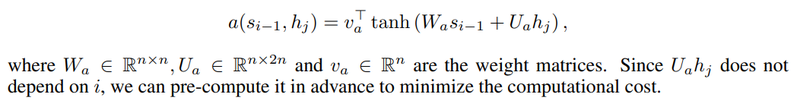

https://arxiv.org/pdf/1409.0473.pdf

**Q. 위 시각화 글의 2단계에서, Softmax의 결괏값은 Encoder에 매 스텝마다 입력으로 들어온 각 단어의 독립적인 비중이라고 생각해도 좋은가요? (Hint: RNN의 Hidden State는 어떤 과정을 통해 생기죠?)**

<details>
<summary>💡예시답안 확인하기💡</summary>

독립적이지 않다. RNN은 단어의 정보를 순차적으로 적립하여 Hidden State를 구축하기 때문에 순방향 RNN의 첫 단어는 그 단어의 정보만을 담았을지언정 그 이후 스텝들은 거쳐온 모든 단어의 정보를 포함하고 있다.
</details>

**Q. 위 시각화 글의 4단계에서, Hidden State에 Softmax 값을 곱하여 Alignment 값을 얻었습니다. 해당 값을 모두 더하여 최종적인 컨텍스트 벡터를 얻는데요, 다 더해지면 값이 모호해지지 않을까요? 이는 어떤 의미를 갖나요? 간단히 설명하고 기존 Seq2seq의 고정 크기의 컨텍스트 벡터와 비교해봅시다. (Hint: Word2Vec의 연산을 기억하나요?)**

<details>
<summary>💡예시답안 확인하기💡</summary>

컨텍스트 벡터가 핵심 단어(비중이 큰 단어)에 가장 근접하게 다가서되, 주변 단어에도 각각의 비중만큼 영향을 받아 문장을 적합한 위치에 매핑되게 한다.

기존 RNN의 최종 스텝을 컨텍스트 벡터로 쓰던 방식은 항상 고정된 비중을 사용(마지막에 등장한 단어가 큰 비중)하는 셈이므로 Bahdanau의 방식보다 문맥 정보를 유연하게 반영하지 못한다.
</details>

**Q. Bahdanau 방식에서 생성된 컨텍스트 벡터는 어떤 방식으로 Decoder에서 사용되나요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

Decoder의 현재 스텝 입력(이전 출력 단어의 Embedding)과 Concatenate되어 Decoder RNN의 입력으로 들어가고, 이를 바탕으로 현재 스텝의 출력을 생성한다.
</details>

Bahdanau가 제안한 Attention은 하나의 Baseline이 되어 지금도 여러 기법을 시험하는 데에 멋진 중심점이 되어주고 있습니다. 멋진 기술들의 공통점은 구현한 것을 봤을 때도 이해가 정말 잘 된다는 것이죠! 여기까지의 개념설명이 명확히 와닿지 않았더라도, 구현을 살펴보며 복습을 해봅시다!

> **참고**: `BahdanauAttention` 클래스는 앞의 "LSTM Decoder" 섹션에서 이미 정의해두었으므로, 여기서는 다시 정의하지 않고 그대로 재사용합니다. 아래는 클래스 동작을 확인해보기 위한 간단한 데모 코드입니다.

In [ ]:
# 위 "LSTM Decoder" 섹션에서 이미 정의한 BahdanauAttention 클래스를 그대로 사용합니다 (재정의하지 않습니다).

# 설정
W_size = 512

# 모델 생성
attention = BahdanauAttention(W_size)

# 입력 데이터 (배치 크기 = 1)
enc_state = torch.rand((1, 10, 512))  # (batch, seq_len, hidden_dim)
dec_state = torch.rand((1, 512))  # (batch, hidden_dim)

# 실행
_ = attention(enc_state, dec_state)

This cell defines the `BahdanauAttention` class, implementing the Bahdanau attention mechanism. It consists of three linear layers: `W_decoder`, `W_encoder`, and `W_combine`, which are used to calculate the alignment scores. The `forward` method takes the encoder's hidden states (`H_encoder`) and the decoder's current hidden state (`H_decoder`). It projects these hidden states into a common feature space, calculates an alignment score using `torch.tanh` and `W_combine`, and then applies a softmax function to get the attention weights. Finally, it computes the context vector by taking a weighted sum of the original encoder hidden states using these attention weights. The shapes of intermediate tensors are printed for better understanding, and the final attention weights are shown.

Encoder의 모든 스텝에 대한 Hidden State를 100차원의 벡터 공간으로 매핑 `(1, 10, 100)` 하고, Decoder의 현재 스텝에 대한 Hidden State 역시 100차원의 벡터 공간으로 매핑 `(1, 1, 100)`해 **두 State의 합으로 정의된 Score** `(1, 10, 1)` **를 구하는 모습**입니다. Softmax를 거쳐 나온 값은 0-1 사이의 값으로 각 단어가 차지하는 비중을 의미하겠죠? 예시에서는 랜덤한 값을 사용했기 때문에 비중이 비슷비슷하지만 실제 단어로 적용시켜보면 **유사한 단어에 높은 비중을 할당**하게 된답니다! 그것을 시각화하면 아래와 같은 그림을 보실 수 있습니다.

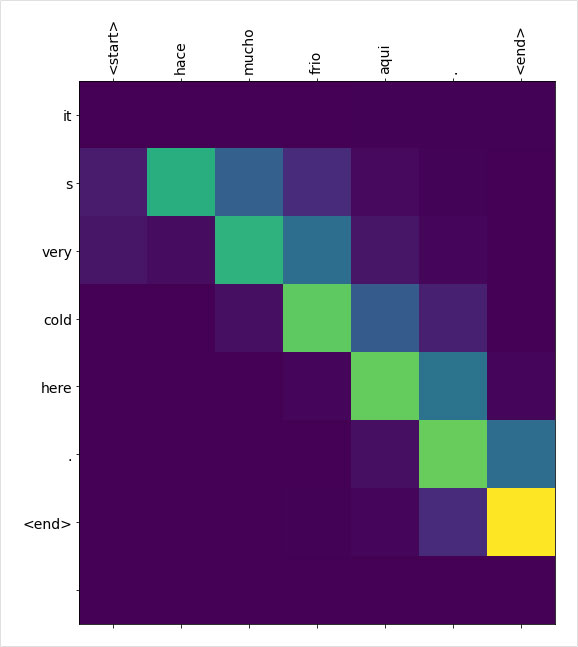

[Attention Map]

https://www.tensorflow.org/tutorials/text/nmt_with_attention?hl=ko

# Attention! (2) Luong Attention

## Luong Attention
---
Luong의 Attention은 Bahdanau의 방식을 약간 발전시킨 형태입니다. Decoder의 현재 Hidden State를 구하기 위해 한 스텝 이전의 Hidden State를 활용하는 것은 연산적으로 비효율적입니다. 이는 RNN의 연산 형태 때문인데, 자세한 내용은 아래 웹페이지에서 확인하시죠! 수식적인 부분은 완벽하게 이해하지 않아도 좋으니, Luong의 아이디어에 중점을 맞추도록 합니다.

- [[Attention] Luong Attention 개념 정리](https://hcnoh.github.io/2019-01-01-luong-attention)

**Q. 저자들은 4가지 Score 함수를 제시하였습니다. 각각은 무엇인가요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

Dot, General, Concat, Location
</details>

정리 글을 읽어 보셨다면, 논문도 함께 첨부하니 멋진 아이디어가 인상 깊었다면 살펴보세요!

> [Effective Approaches to Attention-based Neural Machine Translation](https://arxiv.org/pdf/1508.04025.pdf)

**Q. 4가지 Score 함수 중, 가장 합리적인 성능을 보이는 함수는 어떤 함수인가요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

General
</details>

가장 좋은 성능을 보인 Score 함수는 아래와 같죠? 이를 기반으로 구현을 해보겠습니다.

$$\operatorname{Score}\left(H_{\text {target }}, H_{\text {source }}\right)=H_{\text {target }}^T \times W_{\text {combine }} \times H_{\text {source }}$$

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LuongAttention(nn.Module):
    def __init__(self, units):
        super(LuongAttention, self).__init__()
        self.W_combine = nn.Linear(units, units)  # Encoder hidden state 변환

    def forward(self, H_encoder, H_decoder):
        print("[ H_encoder ] Shape:", H_encoder.shape)  # (batch, seq_len, hidden_dim)

        WH = self.W_combine(H_encoder)  # (batch, seq_len, hidden_dim)
        print("[ W_encoder X H_encoder ] Shape:", WH.shape)

        H_decoder = H_decoder.unsqueeze(1)  # (batch, 1, hidden_dim)
        alignment = torch.bmm(WH, H_decoder.transpose(1, 2))  # (batch, seq_len, 1)
        print("[ Score_alignment ] Shape:", alignment.shape)

        attention_weights = F.softmax(alignment, dim=1)  # (batch, seq_len, 1)
        print("\n최종 Weight:\n", attention_weights.squeeze(-1).detach().numpy())

        attention_weights = attention_weights.squeeze(-1)  # (batch, seq_len)
        context_vector = torch.bmm(attention_weights.unsqueeze(1), H_encoder)  # (batch, 1, hidden_dim)
        context_vector = context_vector.squeeze(1)  # (batch, hidden_dim)

        return context_vector, attention_weights

This cell defines the `LuongAttention` class, implementing the Luong attention mechanism. It uses a single linear layer, `W_combine`, to transform the encoder's hidden states. In the `forward` method, it first transforms the encoder hidden states, then computes the alignment scores by performing a batch matrix multiplication (`torch.bmm`) between the transformed encoder states and the decoder's hidden state (transposed). It applies softmax to get attention weights and then calculates the context vector as a weighted sum of the original encoder hidden states. Similar to Bahdanau attention, intermediate tensor shapes are printed, and the final attention weights are displayed.

이 셀은 Luong 어텐션 메커니즘을 구현하는 `LuongAttention` 클래스를 정의합니다. 이 클래스는 인코더의 은닉 상태를 변환하기 위해 단일 선형 레이어인 `W_combine`을 사용합니다. `forward` 메서드에서는 먼저 인코더의 은닉 상태를 변환한 다음, 변환된 인코더 상태와 디코더의 은닉 상태(전치된) 간의 배치 행렬 곱셈(`torch.bmm`)을 수행하여 정렬 점수를 계산합니다. 이 점수에 소프트맥스를 적용하여 어텐션 가중치를 얻은 다음, 원본 인코더 은닉 상태의 가중합으로 컨텍스트 벡터를 계산합니다. Bahdanau 어텐션과 유사하게 중간 텐서의 형태가 출력되며, 최종 어텐션 가중치도 표시됩니다.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\n--- Testing LuongAttention with Varying Sequence Lengths ---\n")

# Initialize LuongAttention
luong_attention_test = LuongAttention(emb_size)

# Test with a shorter sequence length (e.g., 5)
print("Testing with sequence length = 5:")
enc_state_short = torch.rand((1, 5, emb_size))  # (batch, seq_len=5, hidden_dim)
dec_state_short = torch.rand((1, emb_size))  # (batch, hidden_dim)
context_short, weights_short = luong_attention_test(enc_state_short, dec_state_short)
print(f"Context Vector Shape (short): {context_short.shape}")
print(f"Attention Weights Shape (short): {weights_short.shape}")

print("\nTesting with sequence length = 15:")
# Test with a longer sequence length (e.g., 15)
enc_state_long = torch.rand((1, 15, emb_size))  # (batch, seq_len=15, hidden_dim)
dec_state_long = torch.rand((1, emb_size))  # (batch, hidden_dim)
context_long, weights_long = luong_attention_test(enc_state_long, dec_state_long);
print(f"Context Vector Shape (long): {context_long.shape}")
print(f"Attention Weights Shape (long): {weights_long.shape}")


--- Testing LuongAttention with Varying Sequence Lengths ---

Testing with sequence length = 5:
[ H_encoder ] Shape: torch.Size([1, 5, 256])
[ W_encoder X H_encoder ] Shape: torch.Size([1, 5, 256])
[ Score_alignment ] Shape: torch.Size([1, 5, 1])

최종 Weight:
 [[0.01193878 0.6992089  0.0145547  0.05887963 0.21541794]]
Context Vector Shape (short): torch.Size([1, 256])
Attention Weights Shape (short): torch.Size([1, 5])

Testing with sequence length = 15:
[ H_encoder ] Shape: torch.Size([1, 15, 256])
[ W_encoder X H_encoder ] Shape: torch.Size([1, 15, 256])
[ Score_alignment ] Shape: torch.Size([1, 15, 1])

최종 Weight:
 [[0.12384348 0.3006349  0.11534043 0.04489109 0.01770738 0.0144226
  0.00356185 0.02741145 0.01773661 0.02699174 0.07034246 0.11769989
  0.08571782 0.00992357 0.02377466]]
Context Vector Shape (long): torch.Size([1, 256])
Attention Weights Shape (long): torch.Size([1, 15])


 H_encoder: 인코더의 모든 은닉 상태로, 입력 시퀀스의 길이와 임베딩 크기에 따라 (배치 크기, 시퀀스 길이, 임베딩 크기) 형태를 가집니다.

W_encoder X H_encoder: LuongAttention 내에서 W_combine 레이어를 통해 변환된 인코더 은닉 상태입니다. 형태는 H_encoder와 동일합니다.

Score_alignment: 디코더의 현재 은닉 상태와 변환된 인코더 은닉 상태 간의 정렬 점수(alignment score)입니다. (배치 크기, 시퀀스 길이, 1) 형태를 가집니다.

최종 Weight: Softmax 함수를 거쳐 정규화된 어텐션 가중치입니다. 이 가중치는 디코딩 시 각 인코더 토큰의 상대적 중요도를 나타냅니다. 합이 1인 확률 분포를 이룹니다.

Context Vector Shape: 어텐션 가중치로 가중합된 인코더 은닉 상태들의 결과 벡터입니다. (배치 크기, 임베딩 크기) 형태를 가집니다.

Attention Weights Shape: 어텐션 가중치 자체의 최종 형태입니다. (배치 크기, 시퀀스 길이) 형태를 가집니다.

### 데이터셋 다운로드 및 로드

한글-영어 병렬 말뭉치 데이터셋을 사용하기 위해, 먼저 훈련 데이터 (`korean-english-park.train.ko`와 `korean-english-park.train.en`)를 다운로드합니다. 이 파일들은 각각 한글 문장과 그에 대응하는 영어 문장을 포함하고 있습니다.

In [ ]:
# Clone the Korean-English parallel corpus repository
!git clone https://github.com/jungyeul/korean-parallel-corpora.git

Cloning into 'korean-parallel-corpora'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 176 (delta 20), reused 0 (delta 0), pack-reused 131 (from 1)
Receiving objects: 100% (176/176), 20.48 MiB | 14.40 MiB/s, done.
Resolving deltas: 100% (63/63), done.


다운로드한 파일을 로드하고 각 언어의 첫 몇 줄을 확인하여 데이터 형식을 이해해 보겠습니다.

In [ ]:
import os
import tarfile

# Define the path to the tar.gz file
tar_file_path = 'korean-parallel-corpora/korean-english-news-v1/korean-english-park.train.tar.gz'
# Define the directory to extract to
extract_dir = 'korean-parallel-corpora/korean-english-news-v1/'

# Extract the tar.gz file
print(f"Extracting {tar_file_path} to {extract_dir}...")
with tarfile.open(tar_file_path, 'r:gz') as tar:
    tar.extractall(path=extract_dir)
print("Extraction complete.")

# Check the contents of the extracted directory to confirm paths
print("\n--- Contents of extracted directory ---")
!ls -R {extract_dir}

# Load the extracted files
with open(os.path.join(extract_dir, 'korean-english-park.train.ko'), 'r', encoding='utf-8') as f_ko:
    korean_sentences = f_ko.readlines()

with open(os.path.join(extract_dir, 'korean-english-park.train.en'), 'r', encoding='utf-8') as f_en:
    english_sentences = f_en.readlines()

print("\n--- Sample Korean Sentences ---")
for i in range(5):
    print(korean_sentences[i].strip())

print("\n--- Sample English Sentences ---")
for i in range(5):
    print(english_sentences[i].strip())

Extracting korean-parallel-corpora/korean-english-news-v1/korean-english-park.train.tar.gz to korean-parallel-corpora/korean-english-news-v1/...
Extraction complete.

--- Contents of extracted directory ---


/tmp/ipykernel_2323/2653622378.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


korean-parallel-corpora/korean-english-news-v1/:
korean-english-park.dev.tar.gz	 korean-english-park.train.ko
korean-english-park.test.tar.gz  korean-english-park.train.tar.gz
korean-english-park.train.en	 README.md

--- Sample Korean Sentences ---
개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
그러나 이것은 또한 책상도 필요로 하지 않는다.
79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.

--- Sample English Sentences ---
Much of personal computing is about "can you top this?"
so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
Like all optical mice, But it also doesn't need a desk.
uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.
Intelligence officials have revealed a spate 

In [ ]:
!ls -R korean-parallel-corpora

korean-parallel-corpora:
bible	 korean-english-jhe	 korean-french-jim-v1	      README.md
contrib  korean-english-news-v1  northkorean-english-news-v1

korean-parallel-corpora/bible:
bible-all.en.txt  bible-all.kr.txt  readme.md

korean-parallel-corpora/contrib:
README.md

korean-parallel-corpora/korean-english-jhe:
jhe-koen-dev.en  jhe-koen-dev.ko.pos  jhe-koen-eval.ko	    README.md
jhe-koen-dev.ko  jhe-koen-eval.en     jhe-koen-eval.ko.pos

korean-parallel-corpora/korean-english-news-v1:
korean-english-park.dev.tar.gz	 korean-english-park.train.ko
korean-english-park.test.tar.gz  korean-english-park.train.tar.gz
korean-english-park.train.en	 README.md

korean-parallel-corpora/korean-french-jim-v1:
korean-french-park-v1.test.fr	   korean-french-park-v1.train.ko
korean-french-park-v1.test.ko	   korean-french-park-v1.train.tar.gz
korean-french-park-v1.test.tar.gz  readme.md
korean-french-park-v1.train.fr

korean-parallel-corpora/northkorean-english-news-v1:
northkorean-english.dev.en  no

이제 데이터가 성공적으로 로드되었으니, 다음 단계는 이 데이터를 인코더-디코더 모델에 사용할 수 있도록 전처리하는 것입니다. 이 과정에는 다음이 포함됩니다:

1.  **토큰화 (Tokenization):** 각 문장을 단어 또는 서브워드 단위로 분할합니다.
2.  **어휘 구축 (Vocabulary Building):** 각 언어에 대한 고유한 토큰 목록(어휘)을 생성하고 각 토큰에 정수 인덱스를 할당합니다.
3.  **패딩 (Padding):** 모델에 입력하기 위해 모든 시퀀스의 길이를 동일하게 맞춥니다.
4.  **배치 생성 (Batching):** 여러 문장을 그룹화하여 모델 훈련에 사용할 배치 데이터를 생성합니다.

이후에 이 전처리된 데이터를 사용하여 `Encoder`, `Decoder`, 그리고 `Attention` 메커니즘을 훈련시킬 수 있습니다.

## 데이터 전처리: 토큰화 (Tokenization)

토큰화는 문장을 더 작은 단위(단어 또는 서브워드)로 나누는 과정입니다. 이를 통해 각 단어를 모델의 입력으로 사용할 수 있습니다.

### 영어 토큰화

영어 문장의 경우, NLTK의 `word_tokenize`를 사용하여 단어 단위로 토큰화합니다. 또한, 모든 단어를 소문자로 변환하여 어휘 크기를 줄이고 대소문자 구분을 없앱니다.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# NLTK 데이터 다운로드 (최초 1회 실행 필요)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

english_tokenized_sentences = []
for sentence in english_sentences:
    # 소문자 변환 및 토큰화
    tokens = word_tokenize(sentence.lower())
    english_tokenized_sentences.append(tokens)

print("--- Sample English Tokenized Sentences ---")
for i in range(5):
    print(english_tokenized_sentences[i])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


--- Sample English Tokenized Sentences ---
['much', 'of', 'personal', 'computing', 'is', 'about', '``', 'can', 'you', 'top', 'this', '?', "''"]
['so', 'a', 'mention', 'a', 'few', 'weeks', 'ago', 'about', 'a', 'rechargeable', 'wireless', 'optical', 'mouse', 'brought', 'in', 'another', 'rechargeable', ',', 'wireless', 'mouse', '.']
['like', 'all', 'optical', 'mice', ',', 'but', 'it', 'also', 'does', "n't", 'need', 'a', 'desk', '.']
['uses', 'gyroscopic', 'sensors', 'to', 'control', 'the', 'cursor', 'movement', 'as', 'you', 'move', 'your', 'wrist', ',', 'arm', ',', 'whatever', 'through', 'the', 'air', '.']
['intelligence', 'officials', 'have', 'revealed', 'a', 'spate', 'of', 'foiled', 'plots', 'on', 'ships', 'in', 'southeast', 'asia', 'and', 'are', 'warning', 'that', 'a', 'narrow', 'stretch', 'of', 'water', 'carrying', 'almost', 'one', 'third', 'of', 'the', 'world', "'s", 'maritime', 'trade', 'is', 'vulnerable', 'to', 'a', 'terror', 'attack', '.']


### 한국어 토큰화

한국어는 교착어의 특성 때문에 단순한 공백 기반 토큰화로는 의미 있는 단위를 얻기 어렵습니다. 형태소 분석기를 사용하는 것이 일반적입니다. 여기서는 `konlpy` 라이브러리의 `Mecab` 형태소 분석기를 사용하는 것을 권장하지만, Colab 환경에서 `konlpy` 설치가 복잡할 수 있으므로, 간단히 공백 기준으로 토큰화하는 예시를 먼저 보여드립니다. 실제 프로젝트에서는 `Mecab`과 같은 형태소 분석기를 사용해야 더 좋은 성능을 얻을 수 있습니다.

**참고: `konlpy` 설치 가이드**
```bash
!pip install konlpy
!apt-get update
!apt-get install g++ openjdk-8-jdk-headless -qq > /dev/null
!JAVA_HOME=/usr/lib/jvm/java-8-openjdk-amd64
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
```

In [ ]:
# from konlpy.tag import Mecab
# mecab = Mecab()

korean_tokenized_sentences = []
for sentence in korean_sentences:
    # Mecab 형태소 분석기 사용 (주석 처리됨)
    # tokens = mecab.morphs(sentence)
    # 간단한 공백 기준 토큰화 (임시)
    tokens = sentence.strip().split()
    korean_tokenized_sentences.append(tokens)

print("--- Sample Korean Tokenized Sentences ---")
for i in range(5):
    print(korean_tokenized_sentences[i])

--- Sample Korean Tokenized Sentences ---
['개인용', '컴퓨터', '사용의', '상당', '부분은', '"이것보다', '뛰어날', '수', '있느냐?"']
['모든', '광마우스와', '마찬가지', '로', '이', '광마우스도', '책상', '위에', '놓는', '마우스', '패드를', '필요로', '하지', '않는다.']
['그러나', '이것은', '또한', '책상도', '필요로', '하지', '않는다.']
['79.95달러하는', '이', '최첨단', '무선', '광마우스는', '허공에서', '팔목,', '팔,', '그외에', '어떤', '부분이든', '그', '움직임에따라', '커서의', '움직임을', '조절하는', '회전', '운동', '센서를', '사용하고', '있다.']
['정보', '관리들은', '동남', '아시아에서의', '선박들에', '대한', '많은', '(테러)', '계획들이', '실패로', '돌아갔음을', '밝혔으며,', '세계', '해상', '교역량의', '거의', '3분의', '1을', '운송하는', '좁은', '해로인', '말라카', '해협이', '테러', '공격을', '당하기', '쉽다고', '경고하고', '있다.']


## 데이터 전처리: 어휘 구축 (Vocabulary Building)

토큰화된 문장을 모델이 이해할 수 있는 숫자 시퀀스로 변환하기 위해 어휘를 구축합니다. 각 언어별로 고유한 토큰 집합을 만들고, 각 토큰에 고유한 정수 인덱스를 할당합니다. 또한, 특수 토큰(`[PAD]`, `[UNK]`, `[SOS]`, `[EOS]`)을 어휘에 추가합니다.

- `[PAD]`: 문장의 길이를 맞추기 위한 패딩 토큰
- `[UNK]`: 어휘에 없는 단어를 나타내는 알 수 없는 토큰
- `[SOS]`: 문장의 시작을 나타내는 토큰
- `[EOS]`: 문장의 끝을 나타내는 토큰

In [ ]:
from collections import Counter

def build_vocab(sentences, special_tokens=None):
    word_counts = Counter(word for sentence in sentences for word in sentence)
    # 빈도수가 높은 순서대로 정렬하여 인덱스 부여
    sorted_vocab = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
    word_to_idx = {word: idx for idx, (word, _) in enumerate(sorted_vocab)}

    if special_tokens:
        # 특수 토큰을 어휘의 앞부분에 추가
        offset = len(special_tokens)
        for token in reversed(special_tokens): # 역순으로 넣어주어 0, 1, 2, ... 인덱스 할당
            if token not in word_to_idx:
                word_to_idx = {token: idx for idx, token in enumerate(special_tokens)} | {word: idx + offset for word, idx in word_to_idx.items()}

    idx_to_word = {idx: word for word, idx in word_to_idx.items()}
    return word_to_idx, idx_to_word

special_tokens = ['[PAD]', '[UNK]', '[SOS]', '[EOS]']

korean_word_to_idx, korean_idx_to_word = build_vocab(korean_tokenized_sentences, special_tokens)
english_word_to_idx, english_idx_to_word = build_vocab(english_tokenized_sentences, special_tokens)

print("--- Korean Vocabulary Size ---", len(korean_word_to_idx))
print("--- English Vocabulary Size ---", len(english_word_to_idx))

print("\n--- Sample Korean Vocab (first 10) ---")
for i, (word, idx) in enumerate(korean_word_to_idx.items()):
    if i >= 10: break
    print(f"{word}: {idx}")

print("\n--- Sample English Vocab (first 10) ---")
for i, (word, idx) in enumerate(english_word_to_idx.items()):
    if i >= 10: break
    print(f"{word}: {idx}")

--- Korean Vocabulary Size --- 241556
--- English Vocabulary Size --- 57237

--- Sample Korean Vocab (first 10) ---
[PAD]: 0
[UNK]: 1
[SOS]: 2
[EOS]: 3
이: 4
밝혔다.: 5
말했다.: 6
있다.: 7
수: 8
있는: 9

--- Sample English Vocab (first 10) ---
[PAD]: 0
[UNK]: 1
[SOS]: 2
[EOS]: 3
the: 4
,: 5
.: 6
to: 7
of: 8
a: 9


## 데이터 전처리: 패딩 (Padding)

딥러닝 모델의 입력으로 사용하기 위해 모든 시퀀스의 길이를 동일하게 맞춰야 합니다. 이를 위해 `[PAD]` 토큰을 사용하여 짧은 문장을 최대 길이까지 채웁니다. 또한, 모델에 따라 입력 시퀀스의 길이를 제한하는 `MAX_LENGTH`를 설정할 수 있습니다.

In [ ]:
import torch

MAX_LENGTH = 50 # 예시로 최대 길이를 50으로 설정

def pad_sequences(sentences, word_to_idx, max_length, padding_token='[PAD]'):
    padded_sequences = []
    padding_idx = word_to_idx[padding_token]

    for sentence in sentences:
        # 문장을 정수 인덱스로 변환하고 EOS 토큰 추가
        indexed_sentence = [word_to_idx.get(word, word_to_idx['[UNK]']) for word in sentence]
        indexed_sentence.append(word_to_idx['[EOS]'])

        if len(indexed_sentence) > max_length:
            # 최대 길이를 초과하면 잘라냅니다.
            padded_seq = indexed_sentence[:max_length]
        else:
            # 최대 길이까지 패딩 토큰으로 채웁니다.
            padded_seq = indexed_sentence + [padding_idx] * (max_length - len(indexed_sentence))

        padded_sequences.append(padded_seq)

    return torch.tensor(padded_sequences, dtype=torch.long)

# 한국어 문장 패딩
korean_padded_sequences = pad_sequences(korean_tokenized_sentences, korean_word_to_idx, MAX_LENGTH)

# 영어 문장 패딩
english_padded_sequences = pad_sequences(english_tokenized_sentences, english_word_to_idx, MAX_LENGTH)

print("--- Sample Korean Padded Sequences ---")
for i in range(5):
    print(korean_padded_sequences[i].tolist())

print("\n--- Sample English Padded Sequences ---")
for i in range(5):
    print(english_padded_sequences[i].tolist())

print(f"\nKorean Padded Sequences Shape: {korean_padded_sequences.shape}")
print(f"English Padded Sequences Shape: {english_padded_sequences.shape}")

--- Sample Korean Padded Sequences ---
[14611, 519, 25103, 12535, 4615, 101438, 101439, 8, 101440, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[60, 101441, 4003, 2630, 4, 101442, 34768, 2046, 19616, 44058, 101443, 3523, 195, 803, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[27, 1095, 48, 101444, 3523, 195, 803, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[101445, 4, 2631, 2677, 101446, 101447, 101448, 19617, 101449, 211, 101450, 41, 59083, 101451, 2416, 25104, 29184, 1724, 29185, 3166, 7, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1312, 1096, 9688, 44059, 59084, 11, 32, 59085, 44060, 10330, 101452, 14612, 66, 8603, 101453, 234, 4004, 34769, 19618, 8152, 101454, 101455, 101456, 278, 301, 44061, 19619, 7112, 7, 3, 0, 0,

## 데이터 전처리: 배치 생성 (Batching)

패딩된 시퀀스를 모델 훈련에 적합한 배치 형태로 만듭니다. `torch.utils.data.Dataset`과 `torch.utils.data.DataLoader`를 사용하여 데이터를 효율적으로 관리하고 배치 단위로 로드할 수 있습니다.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, source_sequences, target_sequences):
        self.source_sequences = source_sequences
        self.target_sequences = target_sequences

    def __len__(self):
        return len(self.source_sequences)

    def __getitem__(self, idx):
        return self.source_sequences[idx], self.target_sequences[idx]

# 데이터셋 생성
translation_dataset = TranslationDataset(korean_padded_sequences, english_padded_sequences)

# 데이터로더 생성 (배치 크기는 위에서 정의한 batch_size 변수를 사용)
batch_size = 64 # 편의상 64로 설정, 필요에 따라 조정 가능

translation_dataloader = DataLoader(translation_dataset, batch_size=batch_size, shuffle=True)

# 첫 번째 배치 확인
for i, (source, target) in enumerate(translation_dataloader):
    print(f"Batch {i+1}:")
    print(f"  Source (Korean) Batch Shape: {source.shape}")
    print(f"  Target (English) Batch Shape: {target.shape}")
    print(f"  Sample Source (Korean) Sequence: {source[0].tolist()}")
    print(f"  Sample Target (English) Sequence: {target[0].tolist()}")
    if i == 0: # 첫 번째 배치만 출력
        break

Batch 1:
  Source (Korean) Batch Shape: torch.Size([64, 50])
  Target (English) Batch Shape: torch.Size([64, 50])
  Sample Source (Korean) Sequence: [4, 2434, 18508, 16781, 6703, 1124, 288, 3679, 333, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sample Target (English) Sequence: [23, 200, 567, 49, 31, 44, 139, 5, 164, 9, 559, 207, 8, 4, 2985, 3342, 162, 833, 5868, 6, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Seq2Seq Model with Bahdanau Attention

Now, we'll combine the `Encoder`, `Decoder`, and `BahdanauAttention` into a single `Seq2Seq` model. This model will take source language sequences, encode them, and then decode them into target language sequences using the attention mechanism to focus on relevant parts of the source during decoding.

In [ ]:
import random

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        # source = [batch size, source len]
        # target = [batch size, target len]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if 0.75 we use ground-truth inputs 75% of the time

        batch_size = source.shape[0]
        target_len = target.shape[1]
        target_vocab_size = self.decoder.vocab_size

        # tensor to store decoder outputs
        outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(self.device)

        # encoder_outputs is all hidden states of the input sequence, back and forwards
        # hidden is the final forward and backward hidden states
        # cell is the final forward and backward cell states
        encoder_outputs, hidden, cell = self.encoder(source)

        # first input to the decoder is the <sos> token
        # (batch_size, 1) to match decoder's expected input shape
        input_token = target[:, 0].unsqueeze(1)

        for t in range(1, target_len):
            # insert input token, previous hidden and cell states, and encoder outputs
            # then get current output and new hidden and cell states
            output, hidden, cell = self.decoder(input_token, hidden, cell, encoder_outputs)

            # store prediction in tensor of outputs
            # output from decoder is already (batch_size, vocab_size)
            outputs[:, t, :] = output

            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio

            # get the highest predicted token from our predictions
            top1 = output.argmax(1) # Fix: Changed from argmax(2) to argmax(1)

            # if teacher forcing, use actual next token as next input
            # if not, use predicted next token
            # top1 is now (batch_size), so unsqueeze it to (batch_size, 1)
            input_token = target[:, t].unsqueeze(1) if teacher_force else top1.unsqueeze(1)

        return outputs

### Model Initialization

Now we will instantiate the `Encoder`, `Decoder`, and `BahdanauAttention` classes with the defined parameters, and then combine them into the `Seq2Seq` model. We will also move the model to the appropriate device (GPU if available, otherwise CPU).

In [ ]:
# Determine device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Encoder and Decoder parameter setup (using the previously defined values)
INPUT_DIM = len(korean_word_to_idx) # Korean vocabulary size
OUTPUT_DIM = len(english_word_to_idx) # English vocabulary size
ENC_EMB_DIM = emb_size # 256
DEC_EMB_DIM = emb_size # 256
HID_DIM = lstm_size # 512

# Instantiate Encoder
encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM).to(device)

# Instantiate Decoder (note: Decoder needs vocab_size, embedding_dim, hidden_dim)
# The Decoder's LSTM input size combines embedding_dim + HID_DIM from encoder_outputs
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM).to(device)

# Instantiate the Seq2Seq model
model = Seq2Seq(encoder, decoder, device).to(device)

print(model)

Using device: cuda
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(241556, 256)
    (rnn): LSTM(256, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(57237, 256)
    (lstm): LSTM(768, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=57237, bias=True)
    (attention): BahdanauAttention(
      (W_decoder): Linear(in_features=512, out_features=512, bias=True)
      (W_encoder): Linear(in_features=512, out_features=512, bias=True)
      (W_combine): Linear(in_features=512, out_features=1, bias=True)
    )
  )
)


### Initialize Optimizer and Loss Function

To prepare for training, we need to define an optimizer that will update the model's weights and a loss function to measure the difference between the model's predictions and the true target values.

In [ ]:
import torch.optim as optim

# Define Optimizer
# Adam is a popular choice for many deep learning tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define Loss Function
# CrossEntropyLoss is suitable for classification problems like predicting the next word
# We'll ignore predictions for the padding token when calculating loss
PADDING_IDX = english_word_to_idx['[PAD]'] # Get the index for the padding token
criterion = nn.CrossEntropyLoss(ignore_index=PADDING_IDX)

print("Optimizer and Loss Function Initialized.")

Optimizer and Loss Function Initialized.


### Training Function

We'll define a `train` function that handles the training process for one epoch. This includes iterating through the `DataLoader`, performing forward and backward passes, calculating the loss, and updating the model's parameters.

In [ ]:
import time
import math
from tqdm.auto import tqdm

def train(model, iterator, optimizer, criterion, clip, device):
    model.train() # Set the model to training mode

    epoch_loss = 0

    progress_bar = tqdm(iterator, desc="Training", leave=False)
    for i, (src, trg) in enumerate(progress_bar):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad() # Zero out gradients for this batch

        # Forward pass: model predicts target sequence
        # In Seq2Seq model, target is used for teacher forcing (ground truth for decoder input)
        output = model(src, trg) # output = [batch size, target len, output dim]

        # The `CrossEntropyLoss` function expects inputs in a specific shape:
        # `input` (raw predictions): [N, C] where N is the number of samples and C is the number of classes (vocab size)
        # `target` (true labels): [N]
        # We need to reshape `output` and `trg` accordingly.

        # Reshape output to (batch_size * (target_len - 1), output_dim)
        # We ignore the first token ([SOS]) in the target, as the model predicts from the second token onwards.
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim) # Flatten all tokens except SOS token for loss calculation

        # Reshape target to (batch_size * (target_len - 1))
        trg = trg[:, 1:].reshape(-1) # Flatten all tokens except SOS token

        loss = criterion(output, trg) # Calculate loss

        loss.backward() # Backward pass: compute gradients

        # Clip gradients to prevent exploding gradients, common in RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step() # Update model parameters

        epoch_loss += loss.item()

        # 매 배치마다 현재 loss를 progress bar에 표시 (학습이 실제로 진행 중인지 눈으로 확인 가능)
        progress_bar.set_postfix(loss=f"{loss.item():.3f}")

    return epoch_loss / len(iterator)

print("Training function defined.")


Training function defined.


### Evaluation Function

An `evaluate` function will be used to assess the model's performance on a validation or test set. It will be similar to the training function but will set the model to evaluation mode (`model.eval()`) and disable gradient calculations (`torch.no_grad()`).

In [ ]:
from tqdm.auto import tqdm

def evaluate(model, iterator, criterion, device):
    model.eval() # Set the model to evaluation mode

    epoch_loss = 0

    with torch.no_grad(): # Disable gradient calculations
        progress_bar = tqdm(iterator, desc="Evaluating", leave=False)
        for i, (src, trg) in enumerate(progress_bar):
            src = src.to(device)
            trg = trg.to(device)

            # Forward pass: model predicts target sequence (without teacher forcing for evaluation)
            # We'll set teacher_forcing_ratio to 0 for evaluation
            output = model(src, trg, 0) # output = [batch size, target len, output dim]

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg) # Calculate loss

            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=f"{loss.item():.3f}")

    return epoch_loss / len(iterator)

print("Evaluation function defined.")


Evaluation function defined.


### Helper Function for Timing Epochs

To track the duration of each training and evaluation epoch, we'll create a simple helper function.

In [ ]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

print("Epoch timing function defined.")

Epoch timing function defined.


### Main Training Loop

Finally, we will put everything together to train our Seq2Seq model. This loop will iterate for a set number of epochs, performing training and evaluation, and saving the best performing model.

In [ ]:
N_EPOCHS = 10
CLIP = 1.0 # Gradient clipping value

best_valid_loss = float('inf')

print(f"총 {len(translation_dataloader)}개의 배치 x {N_EPOCHS} epoch 학습을 시작합니다...")

for epoch in range(N_EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{N_EPOCHS} 시작 ===")
    start_time = time.time()

    train_loss = train(model, translation_dataloader, optimizer, criterion, CLIP, device)
    # It's common practice to use a separate validation dataset. For simplicity,
    # we are using the entire training dataset as a placeholder for validation here.
    # In a real-world scenario, you would split your data into training, validation, and test sets.
    valid_loss = evaluate(model, translation_dataloader, criterion, device)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # Save the model if it has the best validation loss so far
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

print("\nTraining complete.")


총 1471개의 배치 x 10 epoch 학습을 시작합니다...

=== Epoch 1/10 시작 ===


Training:   0%|          | 0/1471 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1471 [00:00<?, ?it/s]

Epoch: 01 | Time: 18m 36s
	Train Loss: 5.520 | Train PPL: 249.588
	 Val. Loss: 6.123 |  Val. PPL: 456.317

=== Epoch 2/10 시작 ===


Training:   0%|          | 0/1471 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/1471 [00:00<?, ?it/s]

Epoch: 09 | Time: 18m 23s
	Train Loss: 3.642 | Train PPL:  38.181
	 Val. Loss: 4.784 |  Val. PPL: 119.541

=== Epoch 10/10 시작 ===


Training:   0%|          | 0/1471 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1471 [00:00<?, ?it/s]

Epoch: 10 | Time: 18m 21s
	Train Loss: 3.501 | Train PPL:  33.157
	 Val. Loss: 4.722 |  Val. PPL: 112.349

Training complete.


Bahdanau의 Score 함수와는 다르게 하나의 Weight만을 사용하는 것이 특징입니다. 어떤 벡터 공간에 매핑해주는 과정이 없기 때문에 Weight의 크기는 단어 Embedding 크기와 동일해야 연산이 가능합니다. 이 또한 번역에 적용해보고 성능을 비교해본다면 좋겠죠!

# 테스트 문장 예측과 Attention Map 확인 (뉴스 문장)

지금까지 학습시킨 `Seq2Seq + Bahdanau Attention` 모델이 실제로 얼마나 번역을 잘 해내는지, 그리고 번역을 할 때 입력 문장의 어떤 단어에 **집중(Attention)** 했는지를 직접 확인해보겠습니다.

- 학습에는 `korean-english-park.train` 뉴스 말뭉치를 사용했으니, 검증에는 같은 도메인의 **`korean-english-park.test`** 뉴스 문장을 사용합니다.
- 모델이 한 번도 보지 못한 문장이므로, 학습이 잘 되었는지 가늠해보기에 좋습니다.
- 예측 과정은 Teacher Forcing 없이, 모델이 스스로 만든 이전 스텝의 출력을 다음 스텝의 입력으로 사용하는 **Greedy Decoding**으로 진행합니다.

## 1. 뉴스 테스트 문장 불러오기
---

In [ ]:
import os
import tarfile

# 테스트셋 압축 해제 (train과 동일한 디렉토리에 존재)
test_tar_path = 'korean-parallel-corpora/korean-english-news-v1/korean-english-park.test.tar.gz'
extract_dir = 'korean-parallel-corpora/korean-english-news-v1/'

print(f"Extracting {test_tar_path} to {extract_dir}...")
with tarfile.open(test_tar_path, 'r:gz') as tar:
    tar.extractall(path=extract_dir)
print("Extraction complete.")

with open(os.path.join(extract_dir, 'korean-english-park.test.ko'), 'r', encoding='utf-8') as f_ko:
    news_test_ko = f_ko.readlines()

with open(os.path.join(extract_dir, 'korean-english-park.test.en'), 'r', encoding='utf-8') as f_en:
    news_test_en = f_en.readlines()

print(f"뉴스 테스트 문장 개수: {len(news_test_ko)}")
print("\n--- 샘플 확인 ---")
for i in range(3):
    print("KO:", news_test_ko[i].strip())
    print("EN:", news_test_en[i].strip())
    print()

Extracting korean-parallel-corpora/korean-english-news-v1/korean-english-park.test.tar.gz to korean-parallel-corpora/korean-english-news-v1/...
Extraction complete.
뉴스 테스트 문장 개수: 2000

--- 샘플 확인 ---
KO: 토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을 진지하게 받아 들이고 있습니다.
EN: Those involved in the discussions do take seriously the need to address concerns of law enforcement and national security.

KO: 또한 새로운 기술 개발이 어떤 해결책을 제공해 주는데 도움이 될 것이고, 동시 에 통신망 사용자들이 보다 안전하게 통신을 할 수 있도록 도움을 주게 되리라는 희망도 있습니다.
EN: There is also some hope that new technology developments will help to provide some solutions and at the same time helping to make users of the networks more secure in their communications.

KO: 그래서 클리퍼 칩에 대한 개인적인 해결책은 서서히 자취를 감출 것입니다. 그러나 이 문제는 계속 우리 곁에 존재할 것이며, 당분간은 심각한 상태로 존재할 것입니다.
EN: So the individual solution of the clipper chip may fade from sight, but the questions will be with us and will remain serious for some time.



/tmp/ipykernel_2323/4119274200.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


## 2. 한글 폰트 설정 (Attention Map 시각화용)
---
Attention Map의 x축(입력 문장)이 한국어이기 때문에, 시각화를 위해 한글 폰트를 설치하고 `matplotlib`에 등록합니다. (Colab 기준)

In [ ]:
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료 (NanumGothic)")

한글 폰트 설정 완료 (NanumGothic)


## 3. 번역 함수 (Greedy Decoding) 정의
---
학습된 `model`을 그대로 활용해, 새로운 한국어 문장 하나를 입력받아 영어로 번역하고, 매 디코딩 스텝의 Attention Weight를 함께 기록하는 함수를 정의합니다.

`Decoder.forward`는 학습 편의를 위해 `attention_weights`를 반환하지 않으므로, 시각화를 위해 동일한 연산 과정을 그대로 재현하면서 Attention Weight만 별도로 수집합니다.

In [ ]:
def translate_sentence(model, sentence, korean_word_to_idx, english_word_to_idx,
                        english_idx_to_word, device, max_length=MAX_LENGTH):
    model.eval()

    # 학습 때와 동일하게, 공백 기준으로 토큰화합니다.
    source_tokens = sentence.strip().split()

    indices = [korean_word_to_idx.get(tok, korean_word_to_idx['[UNK]']) for tok in source_tokens]
    indices.append(korean_word_to_idx['[EOS]'])
    source_tokens_with_eos = source_tokens + ['[EOS]']

    if len(indices) < max_length:
        indices = indices + [korean_word_to_idx['[PAD]']] * (max_length - len(indices))
    else:
        indices = indices[:max_length]
        source_tokens_with_eos = source_tokens_with_eos[:max_length]

    src_tensor = torch.tensor([indices], dtype=torch.long).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    decoder = model.decoder
    input_token = torch.tensor([[english_word_to_idx['[SOS]']]], dtype=torch.long).to(device)

    predicted_tokens = []
    attention_matrix = []  # 스텝별 Attention Weight를 쌓아 (target_len, source_len) 행렬로 만듭니다.

    for _ in range(max_length):
        with torch.no_grad():
            embedded = decoder.embedding(input_token)  # (1, 1, emb_dim)

            decoder_hidden_for_attention = hidden.squeeze(0)  # (1, hidden_dim)
            context_vector, attn_weights = decoder.attention(encoder_outputs, decoder_hidden_for_attention)
            # attn_weights: (1, source_len, 1)

            context_vector = context_vector.unsqueeze(1)
            embedded_with_context = torch.cat((embedded, context_vector), dim=2)

            output, (hidden, cell) = decoder.lstm(embedded_with_context, (hidden, cell))
            output = decoder.fc(output.squeeze(1))  # (1, vocab_size)

        top1 = output.argmax(1).item()
        attention_matrix.append(attn_weights.squeeze(0).squeeze(-1).detach().cpu().numpy())  # (source_len,)

        if top1 == english_word_to_idx['[EOS]']:
            break

        predicted_tokens.append(english_idx_to_word.get(top1, '[UNK]'))
        input_token = torch.tensor([[top1]], dtype=torch.long).to(device)

    # 실제 사용된(패딩 이전) source 길이 만큼만 Attention을 잘라냅니다.
    src_len = len(source_tokens_with_eos)
    attention_matrix = np.array(attention_matrix)[:, :src_len]

    return predicted_tokens, attention_matrix, source_tokens_with_eos

print("translate_sentence 함수 정의 완료")

translate_sentence 함수 정의 완료


## 4. Attention Map 시각화 함수 정의
---

In [ ]:
def plot_attention(attention_matrix, source_tokens, target_tokens, title=None):
    fig_width = max(6, len(source_tokens) * 0.6)
    fig_height = max(4, len(target_tokens) * 0.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    im = ax.imshow(attention_matrix, cmap='viridis', aspect='auto')

    ax.set_xticks(range(len(source_tokens)))
    ax.set_xticklabels(source_tokens, rotation=90, fontsize=11)
    ax.set_yticks(range(len(target_tokens)))
    ax.set_yticklabels(target_tokens, fontsize=11)

    ax.set_xlabel('입력 문장 (한국어)')
    ax.set_ylabel('예측 문장 (영어)')
    if title:
        ax.set_title(title, fontsize=12)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

print("plot_attention 함수 정의 완료")

plot_attention 함수 정의 완료


## 5. 뉴스 문장으로 최종 확인
---
너무 긴 문장은 Attention Map이 읽기 어려우므로, 토큰 개수가 3~12개인 문장 위주로 5개를 골라 확인합니다.

선택된 뉴스 테스트 문장 인덱스: [11, 13, 14, 15, 18]
[입력 문장]     페도로바는 자신의 오랜 남자 친구와 결혼했을지도 모르며
[정답 번역]     Fedorova might be married to her longtime boyfriend and could be pregnant.
[모델 예측 번역] for bread , 40 , a man .


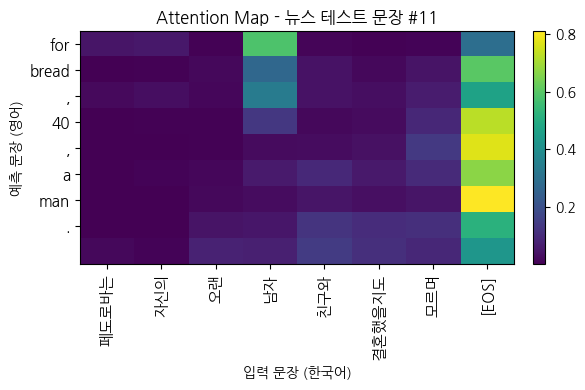

[입력 문장]     다우 존스 산업 평균 지수가 7,683.13으로 189.02 포인트 하락하여 4년내 최저를 기록했다.
[정답 번역]     The Dow Jones industrial average fell 189.02 to 7,683.13, hitting a four-year low.
[모델 예측 번역] in the dow jones industrial average , dow industrials down lower points , or 2.26 at the . .


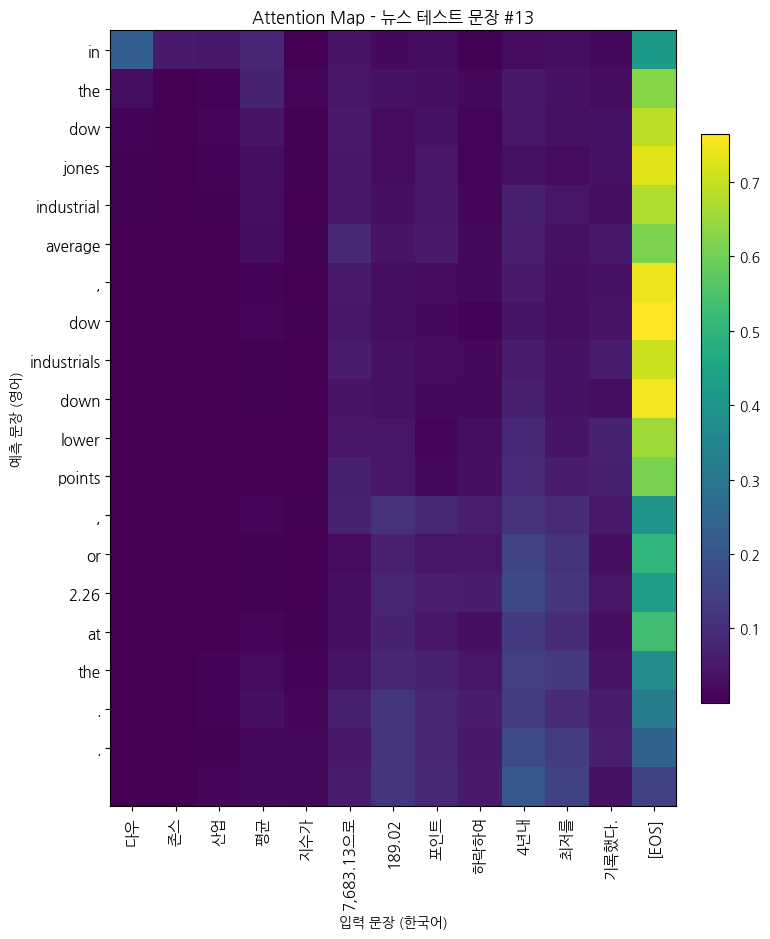

[입력 문장]     나스닥 종합 지수는 1,182.17로 0.23 포인트 하락하여 6년내 최저 수준을 새로 기록했다.
[정답 번역]     The Nasdaq composite fell 0.23 percent to 1,182.17, hitting a new six-year low.
[모델 예측 번역] at the dow jones industrial average plunged down 0.7 percent , or 0.09 percent , or 0.09 percent .


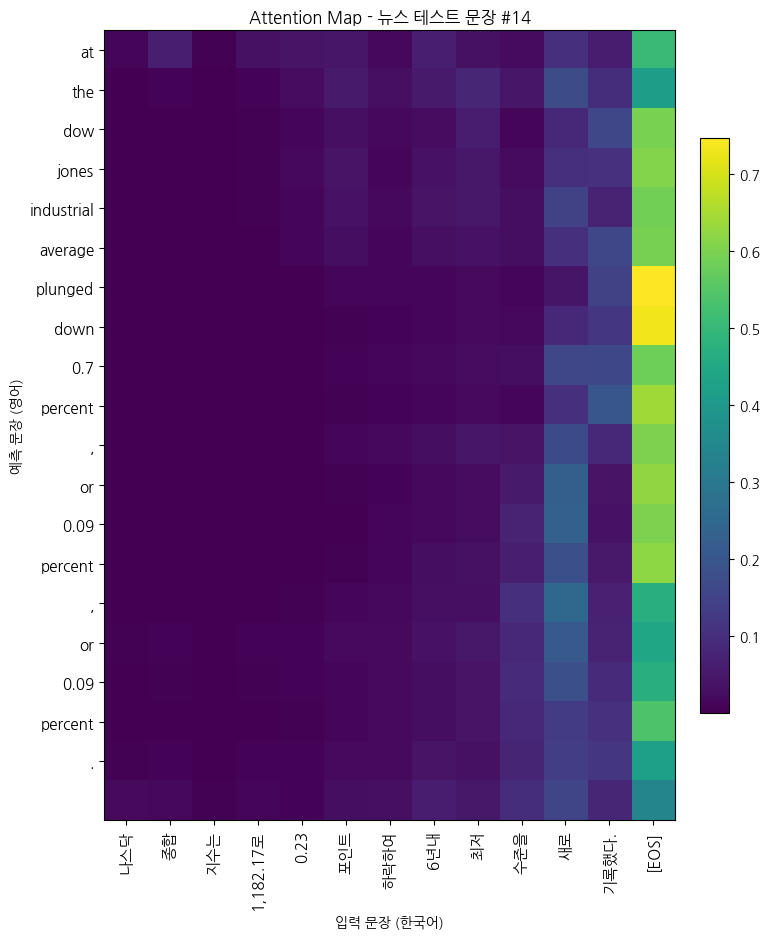

[입력 문장]     도쿄의 니케이 지수는 9291.03으로 0.33 퍼센트 하락했다.
[정답 번역]     Tokyo's Nikkei is off 0.33 percent to 9291.03.
[모델 예측 번역] in the tokyo was closed down the percent , the index .


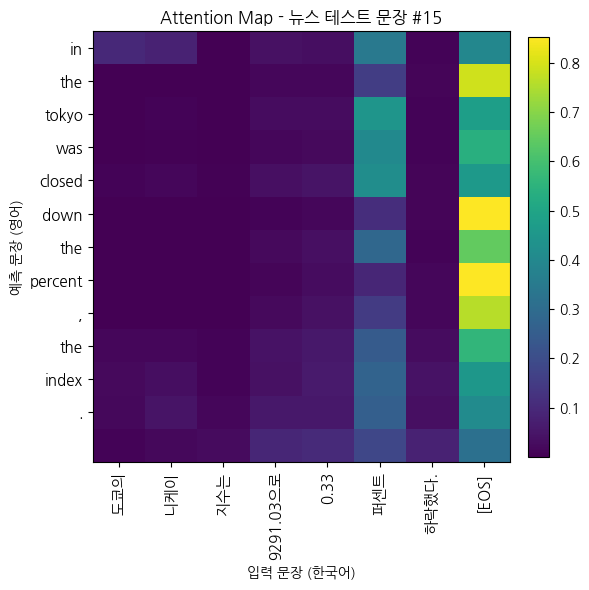

[입력 문장]     이 기구는 국가들이 그러한 공격의 가능성에 대비할 것을 촉구했다.
[정답 번역]     The agency urged nations to prepare for the possibility of such strikes.
[모델 예측 번역] , the countries urged to to to , and to operate .


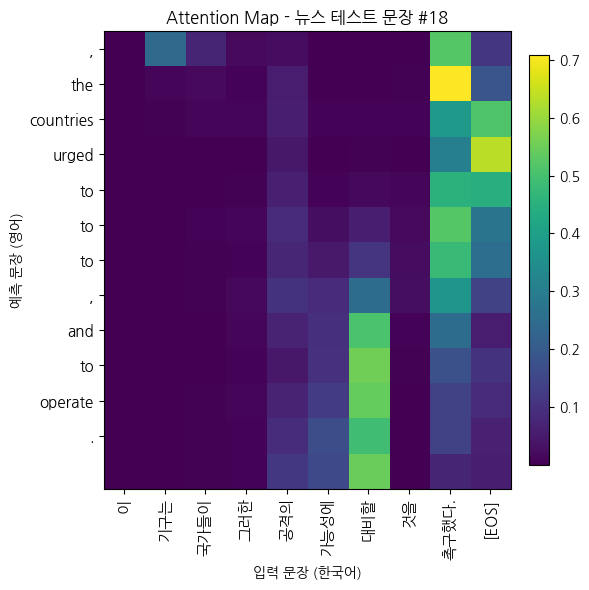

In [ ]:
sample_indices = [
    i for i, s in enumerate(news_test_ko)
    if 3 <= len(s.strip().split()) <= 12
][:5]

print(f"선택된 뉴스 테스트 문장 인덱스: {sample_indices}")

for idx in sample_indices:
    source_sentence = news_test_ko[idx].strip()
    reference_sentence = news_test_en[idx].strip()

    predicted_tokens, attention_matrix, source_tokens = translate_sentence(
        model, source_sentence,
        korean_word_to_idx, english_word_to_idx, english_idx_to_word,
        device
    )
    predicted_sentence = ' '.join(predicted_tokens)

    print("=" * 80)
    print(f"[입력 문장]     {source_sentence}")
    print(f"[정답 번역]     {reference_sentence}")
    print(f"[모델 예측 번역] {predicted_sentence}")

    plot_attention(
        attention_matrix,
        source_tokens,
        predicted_tokens,
        title=f'Attention Map - 뉴스 테스트 문장 #{idx}'
    )

**결과 해석 팁**

- Attention Map의 밝은 부분(노란색에 가까울수록)은 해당 영어 단어를 예측할 때 모델이 그 한국어 단어에 크게 집중했다는 뜻입니다.
- 대각선에 가까운 패턴이 나타난다면, 어순이 비슷한 위치의 단어끼리 정렬(Alignment)되고 있다는 의미로 Bahdanau Attention이 잘 학습되었다고 볼 수 있습니다.
- 학습 Epoch 수가 적거나(`N_EPOCHS = 10`) 데이터 전처리가 단순(형태소 분석기 미사용, 공백 기준 토큰화)하기 때문에, 번역 품질 자체는 완벽하지 않을 수 있습니다. 이 실습의 핵심은 번역 성능 자체보다 **Attention이 실제로 무엇에 집중하는지 시각적으로 확인**하는 데 있습니다.

# 트랜스포머로 가기 전 징검다리?
Seq2seq와 Attention이 폭풍처럼 휩쓸고 난 후, 잠잠해진 NLP 계를 다시 깨운 것은 2016년 구글의 신경망 번역 시스템이었습니다. 놀라운 구조를 제안한 것은 아니나 무려 8개 층을 쌓은 Encoder-Decoder 구조와 Residual Connection은 제법 멋졌죠. 이에 대한 정리 글을 첨부하니 가볍게 읽어 보세요!

- [Google's Neural Machine Translation System.](https://norman3.github.io/papers/docs/google_neural_machine_translation.html)

**Q. GNMT는 Attention을 활용한 Seq2seq 모델인데요, 여기서 Attention은 누구의 방식을 채택했나요? (우리가 배운 두 명 중 한 명이겠죠?)**

<details>
<summary>💡예시답안 확인하기💡</summary>

Bahdanau Attention
</details>

**Q. Residual Connection을 사용했을 때의 이점이 몇 가지 있습니다. 가장 인상 깊게 느껴지는 두 가지만 적어봅시다.**

<details>
<summary>💡예시답안 확인하기💡</summary>

정확도가 올라간다.

학습 속도가 빨라진다.

Gradient Exploding / Vanishing 문제를 해결한다.
</details>

**Q. GNMT에서 언급되는 Copy Model이란 무엇인가요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

한 번도 본 적 없는 단어에 대해서 <UNK> 토큰 처리를 하지 않고 단어를 그대로 복사하여 적당한 위치에 배치하는 모델이다.
</details>

GNMT(Google Neural Machine Translation)는 어쩌면 복선이었을 수도 있는데, 왜냐하면 그 후에 등장한 것이 NLP의 꽃, **트랜스포머(Transformer)** 이기 때문이죠! 앞서 언급한 레이어를 쌓는 구조나 Residual Connection이 트랜스포머와 굉장히 유사하기에 그렇게 느껴지기도 합니다.

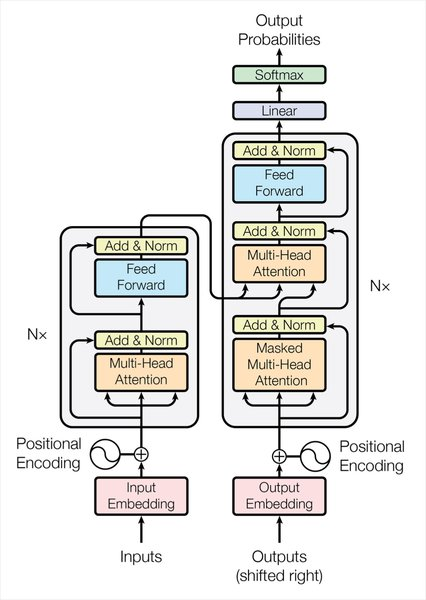

[▲ 트랜스포머의 구조]

트랜스포머 모델은 Multi-Head Attention이라는 개념을 도입해 폭넓은 문맥을 파악하게 하고, 기존의 RNN 구조를 완전히 탈피하여 연산 속도 측면에서도 혁신적인 발전이 일어났습니다! 지금까지도 트랜스포머를 기반으로 한 모델들이 각 분야에서 최고의 성능을 내고 있으니, 그 파급력을 알 만하죠?

궁금하시면 미리 알아보셔도 좋지만 오늘은 여기까지! 자세한 것은 차근차근 알아보도록 합시다.

# 마무리하며
이번 코스에서는 언어 모델의 흐름과 Seq2seq, 그리고 이를 발전시키기 위한 Attention 기법을 두 가지 배웠습니다.
멋진 기술을 배운 만큼 어서 프로젝트를 해보고 싶은 마음이 굴뚝같으실 거라 믿어요 ^*^

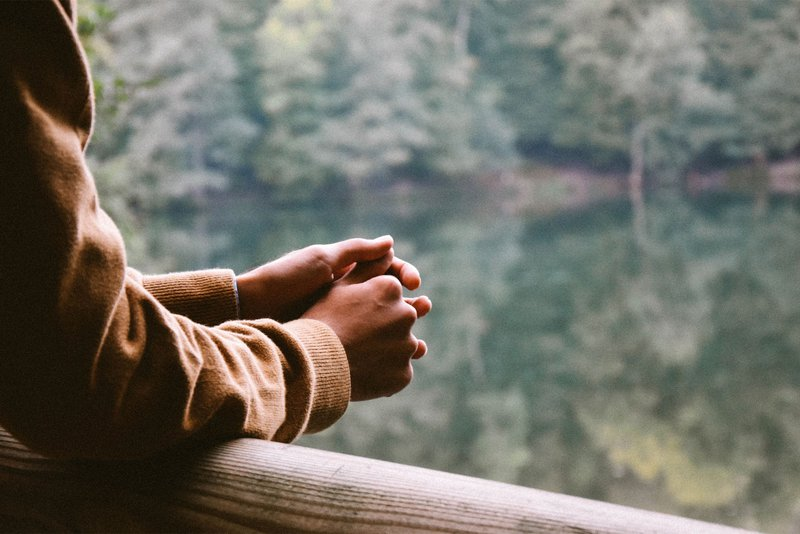

## 종합퀴즈
---
지금까지 여러분들이 얼마나 학습을 충실히 하셨는지 알아볼까 합니다.
여러분의 실력을 쑥쑥 향상시켜줄 수 있는 퀴즈이기도 하므로 배운 내용을 다시 생각하면서 아래의 퀴즈를 풀어보세요. 🤗

**Q. RNN에는 문제점이 있다고 했는데 기억나시나요? 생각해 볼까요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

기울기 소실 문제, 번역에 사용하기는 어렵다는 문제
</details>

**Q. Bahdanau, Luong Attention에 대해서 간단하게 정리해 볼까요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

Attention은 번역 모델에서 입력 문장의 단어와 출력 문장의 단어 사이의 매핑 관계를 찾아내는 메커니즘입니다. 이를 통해 입력 문장의 모든 단어를 고려하면서 출력 문장의 각 단어를 예측합니다. 그러나 문장이 길어질수록 Attention계산에 필요한 계산량이 많아지고, 희소성 문제 등 다양한 문제점이 발생합니다.

Bahdanau Attention은 전체 입력 문장에 대한 정보를 고려하여 출력을 생성하는 반면, Luong Attention은 현재 예측하려는 출력 단어와 관련된 입력 단어에만 집중하여 출력을 생성합니다. 둘 중 어떤 어텐션을 사용할지는 데이터와 모델의 성능에 따라 선택할 수 있습니다.
</details>

종합 퀴즈는 괜찮았나요?
학습을 충실히 하셨다면 쉽게 해결하셨을 것이라 생각합니다.

아무리 완벽해 보이는 기술도 결점을 찾아내는 사람들이 있고, 결점이 곧 발전으로 이어지는 과정을 살펴보니 새삼 경이롭습니다. "역사는 반복된다"는 말이 있듯이, 이번 코스에서 우리가 배운 흐름들은 지금도 논문에 짠! 하고 등장하는 경우가 많습니다. 실제로 필자가 최근에 읽은 ELECTRA 모델 논문에 통계적 언어 모델이 등장해 "몰랐다면 이해하지 못했겠다..."고 생각한 경우도 있었으니까요.

그러니 너무 조급한 마음을 갖지 마시고, **천천히 이해하면서 진행하셔도 괜찮습니다**. 오히려 그게 멀리 갈 수 있는 방법이란 것은 다들 당연히 알고 계시겠죠? 차근차근 나아가서 멋진 연구자, 개발자, 과학자가 되시길 기원합니다! 화이팅!